# 16 — RB-IMM v0.9: Budget-Paced Order-Aware Adaptive Dual

This notebook implements the **predeclared adaptive-dual stage** authorized by
v0.8a. It does not retune the frozen K4 penalty and never accesses the test
split.

## Scientific question

The frozen K4 penalty reduced mean validation risk by 64.9%, but did not provide
reproducible compliance with the loose absolute budget. We therefore test
whether closed-loop dual control can achieve absolute budget compliance without
collapsing trading activity.

## Matched arms

| Label | Dual update | Policy risk context | Outstanding-order signal |
|---|---|---|---|
| `D0_EPISODIC_DUAL` | once at episode end | target budget and current λ | no |
| `D1_REALIZED_PACING` | every fixed block | remaining budget, pace error, λ | no |
| `D2_ORDER_AWARE_PACING` | every fixed block | remaining budget, pace error, λ | yes |

`D2_ORDER_AWARE_PACING` is the single predeclared proposed method. D0 and D1
are mechanistic baselines, not candidates in a post-hoc model-selection grid.

## Frozen protocol

- five matched training seeds are required for primary closure;
- ten training episodes per arm, one immutable primary checkpoint;
- the same training-start stream within every seed;
- the same seven frozen validation windows used by v0.8;
- no test access, checkpoint selection, λ learning-rate search, or K4 retuning;
- atomic episode/checkpoint/evaluation files and exact resume;
- crossed seed × window bootstrap, moving-block sensitivity, seed-level reports;
- final OOS authorization only if the proposed method meets the absolute budget,
  activity, integrity, and non-degenerate order-signal gates.

Run sequentially. Every long training cell contains one branch and safely skips
work already committed to disk.


In [ ]:
from google.colab import drive
from pathlib import Path
import os, sys

MOUNT = Path("/content/drive")
if not (MOUNT / "MyDrive").exists():
    drive.mount(str(MOUNT))

PROJECT_ROOT = MOUNT / "MyDrive" / "RIMM"
if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/RIMM


In [ ]:
import copy
import gc
import hashlib
import inspect
import json
import math
import os
import random
import subprocess
import time
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn.functional as F
import yaml
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


device: cuda
GPU: Tesla T4


## 1. Mathematical formulation

Let the realized normalized inventory exposure at decision (t) be

\[
c_t = \frac{|q_t|}{Q_{\mathrm{ref}}}.
\]

The constrained objective is

\[
\max_\theta J_R(\pi_\theta)
\quad\text{subject to}\quad
J_C(\pi_\theta)
=(1-\gamma_C)\,\mathbb E\!\left[\sum_{t=0}^{T-1}
\gamma_C^t c_t\right]\le B.
\]

The actor uses the Lagrangian

\[
\mathcal L(\theta,\lambda)
=J_R(\pi_\theta)-\lambda\left(J_C(\pi_\theta)-B\right),
\qquad \lambda\ge0.
\]

The cost critic predicts the **normalized** discounted return. This keeps its
scale equal to the published budget. The initial normalized multiplier is
derived from the already frozen K4 coefficient:

\[
\lambda_0=\frac{\kappa_{K4}}{1-\gamma_C},
\]

so that the initial actor objective is scale-equivalent to the fixed-penalty
objective. No new penalty is selected.


## 2. Proposed controller

For (n) elapsed decisions define the fraction of discounted horizon mass

\[
f_n=\frac{1-\gamma_C^n}{1-\gamma_C^T},
\qquad B_n=Bf_n,
\]

and the realized pace error

\[
e_n^{\mathrm{pace}}=\frac{C_n-B_n}{B+\varepsilon},
\qquad
C_n=(1-\gamma_C)\sum_{t=0}^{n-1}\gamma_C^t c_t.
\]

Outstanding bid and ask quantities create inventory risk before a fill is
observed. With conservative fill probability one,

\[
q_n^+=q_n+V_n^{bid},\qquad q_n^-=q_n-V_n^{ask},
\]

\[
\tilde c_n=\frac{\max(|q_n^+|,|q_n^-|)}{Q_{\mathrm{ref}}},
\qquad
a_n=\frac{\max(\tilde c_n-c_n,0)}{B+\varepsilon}.
\]

The proposed arm updates λ from

\[
e_n^{OA}=\operatorname{clip}(e_n^{\mathrm{pace}}+a_n,-2,2),
\]

whereas the realized-pacing ablation uses only (e_n^{pace}). The update is

\[
\lambda_{m+1}=\Pi_{[0,\lambda_{max}]}
\left(\lambda_m+\eta_{block}\,e_m\right).
\]

The actor observes target budget, remaining budget, pace error, current λ, and
the outstanding-order alarm. D0 receives only target budget and λ; D1 receives
the realized pacing variables; D2 additionally receives the order signal.


In [ ]:
SEED = 42
SYMBOL = "ETHUSDT"
RUN_PROFILE = "budget_paced_order_aware"
SPEC_ID = "v09_budget_paced_order_aware_20260927"

MASTER_SEEDS = (10801, 10802, 10803, 10804, 10805)
ARMS = {
    "D0_EPISODIC_DUAL": dict(mode="episodic", order_aware=False),
    "D1_REALIZED_PACING": dict(mode="pacing", order_aware=False),
    "D2_ORDER_AWARE_PACING": dict(mode="pacing", order_aware=True),
}
ARM_LABELS = tuple(ARMS)
PROPOSED_LABEL = "D2_ORDER_AWARE_PACING"
PRIMARY_EPISODE = 10

TRAIN_EPISODE_MINUTES = 30.0
EVAL_EPISODE_MINUTES = 30.0
DECISION_INTERVAL_MS = 500
EXPECTED_HORIZON_STEPS = int(round(
    EVAL_EPISODE_MINUTES * 60_000 / DECISION_INTERVAL_MS
))

TRAIN_CFG = dict(
    replay_capacity=150_000,
    batch_size=256,
    gamma=0.999,
    gamma_cost=0.999,
    tau=0.005,
    policy_delay=2,
    target_noise=0.2,
    noise_clip=0.5,
    exploration_noise=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    encoder_lr=3e-4,
    cost_critic_lr=3e-4,
    update_every=2,
    replay_cost_is_raw=True,
)
IMM_CFG = dict(
    expert_critic_batch_size=128,
    expert_actor_batch_size=256,
    bc_weight_0=1.0,
    imitation_decay_fraction=0.40,
)
V09_CFG = dict(
    training_seeds=list(MASTER_SEEDS),
    minimum_complete_seeds=5,
    target_episodes=PRIMARY_EPISODE,
    snapshot_episodes=(PRIMARY_EPISODE,),
    bootstrap_samples=20_000,
    activity_floor_fraction=0.50,
    controller_block_steps=120,
    controller_error_clip=2.0,
    lambda_max_multiple=8.0,
    primary_budget_name="loose",
    proposed_label=PROPOSED_LABEL,
)
RISK_CFG = dict(gamma_cost=TRAIN_CFG["gamma_cost"], reference_band_N=3.0)
EXPECTED_UPDATES = 22_500
CONTEXT_DIM = 5
BASE_PRIVATE_DIM = 21
AUG_PRIVATE_DIM = BASE_PRIVATE_DIM + CONTEXT_DIM
BASE_STATE_DIM = 89
AUG_STATE_DIM = BASE_STATE_DIM + CONTEXT_DIM

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(json.dumps({
    "spec_id": SPEC_ID,
    "seeds": MASTER_SEEDS,
    "arms": ARM_LABELS,
    "proposed": PROPOSED_LABEL,
    "primary_episode": PRIMARY_EPISODE,
    "test_accessed": False,
}, indent=2))


{
  "spec_id": "v09_budget_paced_order_aware_20260927",
  "seeds": [
    10801,
    10802,
    10803,
    10804,
    10805
  ],
  "arms": [
    "D0_EPISODIC_DUAL",
    "D1_REALIZED_PACING",
    "D2_ORDER_AWARE_PACING"
  ],
  "proposed": "D2_ORDER_AWARE_PACING",
  "primary_episode": 10,
  "test_accessed": false
}


## 3. Project components, data loader and continuity environment


In [ ]:
from mmrl.imm.environment import IMMMarketData, IMMMarketMakingEnv, IMMRewardConfig
from mmrl.imm.tcsa import IMMTCSAEncoder, IMMStateEncoder, TD3Actor, TD3TwinCritic
from mmrl.imm.td3 import clipped_target_action, polyak_update, reconstruct_market_batch
from mmrl.imm.reward import NotionalBpsReward
from mmrl.imm.risk_budget import InventoryExposureCost, RiskIndexedReplayBuffer
from mmrl.simulator import ReplaySimulator
from mmrl.imm.grid import price_tick_to_grid_level

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR = PROJECT_ROOT / "artifacts" / "splits"
SIGNAL_DIR = PROJECT_ROOT / "artifacts" / "imm_predictive_signals"
EXPERT_DIR = PROJECT_ROOT / "artifacts" / "imm_expert_bc"

with open(PROJECT_ROOT / "configs" / "data.yaml", "r", encoding="utf-8") as f:
    DATA_CFG = yaml.safe_load(f)
with open(PROJECT_ROOT / "configs" / "simulator.yaml", "r", encoding="utf-8") as f:
    SIM_CFG = yaml.safe_load(f)

OFFSETS_MS = DATA_CFG["trade_alignment_offset_ms"]
MAX_GAP_MS = int(SIM_CFG["max_gap_ms"])
QUOTE_SIZE = {
    "BTCUSDT": 0.08220875,
    "ETHUSDT": 1.2455625,
    "BNBUSDT": 0.9417,
    "LTCUSDT": 3.8242,
}

ECONOMIC_REWARD_FN = NotionalBpsReward(
    beta=0.01,
    eta=0.0,
    inventory_threshold_N=3.0,
)
RISK_COST_FN = InventoryExposureCost(reference_band_N=RISK_CFG["reference_band_N"])


In [ ]:
def infer_tick_size(states):
    gaps = []
    for i in range(1, 5):
        gaps.append(
            states[f"ask_price_{i+1}"].to_numpy(float)
            - states[f"ask_price_{i}"].to_numpy(float)
        )
        gaps.append(
            states[f"bid_price_{i}"].to_numpy(float)
            - states[f"bid_price_{i+1}"].to_numpy(float)
        )

    x = np.concatenate(gaps)
    x = x[np.isfinite(x) & (x > 0)]
    values, counts = np.unique(np.round(x, 10), return_counts=True)
    return float(values[np.argmax(counts)])


def normalize_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(np.int8).astype(bool)

    mapping = {
        "true": True, "1": True, "t": True, "yes": True,
        "false": False, "0": False, "f": False, "no": False,
    }
    out = series.astype(str).str.lower().str.strip().map(mapping)
    if out.isna().any():
        raise ValueError("unknown boolean value")
    return out.astype(bool)


def load_asset(symbol):
    state_path = PROCESSED_DIR / symbol / "states.parquet"
    split_path = SPLIT_DIR / f"{symbol.lower()}_state_splits.parquet"
    trade_path = RAW_DIR / symbol / "trades.parquet"
    signal_path = SIGNAL_DIR / symbol / "signals.parquet"
    demo_path = EXPERT_DIR / symbol / "expert_demonstrations.parquet"

    state_cols = ["local_timestamp", "mid_price"]
    for side in ["bid", "ask"]:
        for i in range(1, 6):
            state_cols += [f"{side}_price_{i}", f"{side}_qty_{i}"]

    states = (
        pd.read_parquet(state_path, columns=state_cols)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )
    split = (
        pd.read_parquet(split_path)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )
    signals_df = (
        pd.read_parquet(signal_path)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )

    if not np.array_equal(
        pd.to_numeric(states["local_timestamp"]).to_numpy(np.int64),
        pd.to_numeric(signals_df["local_timestamp"]).to_numpy(np.int64),
    ):
        raise ValueError(f"{symbol}: signal timestamp mismatch")

    tick_size = infer_tick_size(states)
    schema = pq.ParquetFile(trade_path).schema.names

    if "timestamp_us" in schema:
        ts_col, multiplier = "timestamp_us", 1
    elif "timestamp_ms" in schema:
        ts_col, multiplier = "timestamp_ms", 1000
    else:
        raise ValueError(f"{symbol}: missing trade timestamp")

    trades = pd.read_parquet(
        trade_path,
        columns=[ts_col, "price", "qty", "is_buyer_maker"],
    ).copy()
    trades["effective_timestamp_us"] = (
        pd.to_numeric(trades[ts_col]).astype(np.int64)
        * int(multiplier)
        + int(OFFSETS_MS[symbol]) * 1000
    )
    trades["price"] = pd.to_numeric(trades["price"]).astype(float)
    trades["qty"] = pd.to_numeric(trades["qty"]).astype(float)
    trades["is_buyer_maker"] = normalize_bool(trades["is_buyer_maker"])
    trades = (
        trades[["effective_timestamp_us", "price", "qty", "is_buyer_maker"]]
        .sort_values("effective_timestamp_us", kind="stable")
        .reset_index(drop=True)
    )

    data = IMMMarketData(
        symbol=symbol,
        states=states,
        split=split,
        trades=trades,
        quote_size=QUOTE_SIZE[symbol],
        tick_size=tick_size,
        lookback=64,
    )

    signals = signals_df[
        ["signal_10s", "signal_60s", "signal_120s", "signal_300s"]
    ].to_numpy(np.float32)
    ready = signals_df["signal_ready"].to_numpy(bool)

    demos = (
        pd.read_parquet(demo_path)
        .sort_values("timestamp_ms", kind="stable")
        .reset_index(drop=True)
    )
    return data, signals, ready, demos


In [ ]:
class ContinuityIMMMarketMakingEnv(IMMMarketMakingEnv):
    def _cancel_offgrid_orders_at_current_decision(self):
        if self.idx is None:
            raise RuntimeError("env not reset")

        ref2 = int(self.data.ref2[int(self.idx)])
        active_orders = list(self.simulator.order_manager.active_orders)
        offgrid_orders = [
            order
            for order in active_orders
            if price_tick_to_grid_level(
                ref2,
                int(order.price_tick),
                k=5,
            ) is None
        ]

        canceled_qty = 0.0
        for order in offgrid_orders:
            canceled_qty += float(
                self.simulator.order_manager.cancel_order(int(order.order_id))
            )

        obs, private_info = self._observation()
        return (
            obs.as_dict(),
            private_info,
            int(len(offgrid_orders)),
            float(canceled_qty),
        )

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)

        before_count = int(info["offgrid_live_child_count"])
        before_qty = float(info["offgrid_live_qty"])

        (
            repaired_obs,
            private_info,
            canceled_count,
            canceled_qty,
        ) = self._cancel_offgrid_orders_at_current_decision()

        if canceled_count != before_count:
            raise AssertionError(
                f"reflection/direct off-grid count mismatch: "
                f"{before_count} vs {canceled_count}"
            )

        info.update(private_info)
        info["offgrid_live_child_count_before_auto_cancel"] = before_count
        info["offgrid_live_qty_before_auto_cancel"] = before_qty
        info["offgrid_auto_canceled_count"] = canceled_count
        info["offgrid_auto_canceled_qty"] = canceled_qty
        info["offgrid_live_child_count_after_auto_cancel"] = int(
            private_info["offgrid_live_child_count"]
        )
        info["offgrid_live_qty_after_auto_cancel"] = float(
            private_info["offgrid_live_qty"]
        )
        info["canceled_qty"] = float(info["canceled_qty"]) + canceled_qty

        if info["offgrid_live_child_count_after_auto_cancel"] != 0:
            raise AssertionError("off-grid order survived auto-cancel")

        return repaired_obs, reward, terminated, truncated, info


In [ ]:
@dataclass
class RiskBundle:
    se: torch.nn.Module
    actor: torch.nn.Module
    reward_critics: torch.nn.Module
    cost_critics: torch.nn.Module
    tse: torch.nn.Module
    tactor: torch.nn.Module
    treward_critics: torch.nn.Module
    tcost_critics: torch.nn.Module
    se_opt: torch.optim.Optimizer
    actor_opt: torch.optim.Optimizer
    reward_critics_opt: torch.optim.Optimizer
    cost_critics_opt: torch.optim.Optimizer


def make_bundle(cfg=TRAIN_CFG):
    market_encoder = IMMTCSAEncoder(
        feature_dim=20,
        lookback=64,
        latent_dim=64,
        tcn_hidden_channels=64,
        tcn_kernel_size=3,
        tcn_dilations=(1, 2, 4),
        tcn_dropout=0.0,
    )
    # The frozen encoder still receives the original 21 private variables.
    # Five controller variables are concatenated after encoding.
    se = IMMStateEncoder(market_encoder, signal_dim=4, private_dim=BASE_PRIVATE_DIM)
    actor = TD3Actor(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))
    reward_critics = TD3TwinCritic(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))
    cost_critics = TD3TwinCritic(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))

    tse = copy.deepcopy(se)
    tactor = copy.deepcopy(actor)
    treward_critics = copy.deepcopy(reward_critics)
    tcost_critics = copy.deepcopy(cost_critics)

    modules = [se, actor, reward_critics, cost_critics,
               tse, tactor, treward_critics, tcost_critics]
    modules = [m.to(DEVICE) for m in modules]
    se, actor, reward_critics, cost_critics, tse, tactor, treward_critics, tcost_critics = modules
    for module in [tse, tactor, treward_critics, tcost_critics]:
        module.eval()
        for p in module.parameters():
            p.requires_grad_(False)

    return RiskBundle(
        se=se, actor=actor, reward_critics=reward_critics, cost_critics=cost_critics,
        tse=tse, tactor=tactor, treward_critics=treward_critics,
        tcost_critics=tcost_critics,
        se_opt=torch.optim.Adam(se.parameters(), lr=cfg["encoder_lr"]),
        actor_opt=torch.optim.Adam(actor.parameters(), lr=cfg["actor_lr"]),
        reward_critics_opt=torch.optim.Adam(
            reward_critics.parameters(), lr=cfg["critic_lr"]
        ),
        cost_critics_opt=torch.optim.Adam(
            cost_critics.parameters(), lr=cfg["cost_critic_lr"]
        ),
    )


def _load_with_zero_expansion(module, source_state, name):
    target_state = module.state_dict()
    converted = {}
    for key, target in target_state.items():
        if key not in source_state:
            raise KeyError(f"{name}: missing source tensor {key}")
        source = source_state[key]
        if tuple(source.shape) == tuple(target.shape):
            converted[key] = source
        elif (source.ndim == target.ndim == 2
              and source.shape[0] == target.shape[0]
              and source.shape[1] < target.shape[1]):
            expanded = torch.zeros_like(target)
            expanded[:, :source.shape[1]] = source.to(expanded.device)
            converted[key] = expanded
        else:
            raise RuntimeError(
                f"{name}.{key}: unsupported expansion {tuple(source.shape)} -> {tuple(target.shape)}"
            )
    module.load_state_dict(converted, strict=True)


def load_shared_expanded_weights(bundle, payload):
    bundle.se.load_state_dict(payload["state_encoder"], strict=True)
    _load_with_zero_expansion(bundle.actor, payload["actor"], "actor")
    _load_with_zero_expansion(
        bundle.reward_critics, payload["reward_critics"], "reward_critics"
    )
    # The normalized cost critic is deliberately initialized from the same seed,
    # not imported from a critic trained on a different target scale.
    bundle.tse.load_state_dict(bundle.se.state_dict())
    bundle.tactor.load_state_dict(bundle.actor.state_dict())
    bundle.treward_critics.load_state_dict(bundle.reward_critics.state_dict())
    bundle.tcost_critics.load_state_dict(bundle.cost_critics.state_dict())
    return bundle


def make_simulator():
    return ReplaySimulator(
        max_gap_ms=MAX_GAP_MS,
        maker_fee_rate=0.0,
        allow_marketable_orders=bool(SIM_CFG["allow_marketable_orders"]),
        allow_inside_spread=bool(SIM_CFG["allow_inside_spread"]),
        allow_beyond_depth5=bool(SIM_CFG["allow_beyond_depth5"]),
        trade_through_fill=bool(SIM_CFG["trade_through_fill"]),
        allow_partial_fills=bool(SIM_CFG["allow_partial_fills"]),
    )


def make_env(data, signals, seed, episode_minutes=TRAIN_EPISODE_MINUTES):
    return ContinuityIMMMarketMakingEnv(
        data=data,
        simulator=make_simulator(),
        decision_interval_ms=DECISION_INTERVAL_MS,
        episode_duration_minutes=float(episode_minutes),
        reward_config=IMMRewardConfig(mode="pnl"),
        signal_matrix=signals,
        seed=seed,
    )


def available_split_name(data, preferred):
    names = {str(x) for x in np.unique(data.split_name)}
    aliases = {"train": ["train"], "validation": ["validation", "val", "valid"], "test": ["test"]}
    for name in aliases.get(preferred, [preferred]):
        if name in names:
            return name
    raise RuntimeError(f"No {preferred!r} split. Available: {sorted(names)}")


def eligible_starts(env, ready, split_name):
    data_ = env.data
    candidate = np.flatnonzero(
        (data_.split_name == split_name) & data_.lookback_ready & ready
    ).astype(np.int64)
    n = len(data_.timestamp_ms)
    episode_right = np.empty(n, dtype=np.int64)
    segment_break = (
        (data_.episode_id[1:] != data_.episode_id[:-1])
        | (data_.split_name[1:] != data_.split_name[:-1])
    )
    left_edges = np.flatnonzero(np.r_[True, segment_break])
    right_edges = np.r_[left_edges[1:] - 1, n - 1]
    for left, right in zip(left_edges, right_edges):
        episode_right[left:right + 1] = right
    available = data_.timestamp_ms[episode_right[candidate]] - data_.timestamp_ms[candidate]
    out = candidate[available >= env.episode_duration_ms]
    if len(out) == 0:
        raise RuntimeError(f"no full-duration starts for split={split_name}")
    return out


In [ ]:
class RiskExpertSampler:
    def __init__(self, data, demos, reward_fn, cost_fn, seed=42):
        self.data = data
        self.rng = np.random.default_rng(seed)

        self.actor_df = demos[demos["bc_valid"]].reset_index(drop=True)
        self.critic_df = demos[demos["critic_valid"]].reset_index(drop=True)
        if len(self.actor_df) == 0 or len(self.critic_df) == 0:
            raise RuntimeError("empty expert subset")

        self.a_idx = self.actor_df["state_idx"].to_numpy(np.int64)
        self.a_private = self.actor_df[
            [f"private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.a_action = self.actor_df[
            [f"expert_action_{j}" for j in range(4)]
        ].to_numpy(np.float32)

        self.c_idx = self.critic_df["state_idx"].to_numpy(np.int64)
        self.c_next = self.critic_df["next_state_idx"].to_numpy(np.int64)
        self.c_private = self.critic_df[
            [f"private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.c_next_private = self.critic_df[
            [f"next_private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.c_action = self.critic_df[
            [f"expert_action_{j}" for j in range(4)]
        ].to_numpy(np.float32)

        rewards, costs = [], []
        for row in self.critic_df.itertuples(index=False):
            reward, _ = reward_fn.compute(
                pnl=float(row.pnl),
                filled_notional=float(row.filled_notional),
                inventory=float(row.inventory_after),
                quote_size=float(data.quote_size),
                mid_price=float(data.mid_price[int(row.next_state_idx)]),
            )
            cost, _ = cost_fn.compute(
                inventory=float(row.inventory_after),
                quote_size=float(data.quote_size),
            )
            rewards.append(reward)
            costs.append(cost)

        self.c_reward = np.asarray(rewards, dtype=np.float32)
        self.c_cost = np.asarray(costs, dtype=np.float32)
        self.c_done = (
            data.episode_id[self.c_idx] != data.episode_id[self.c_next]
        ).astype(np.float32)

    def sample_actor(self, n):
        i = self.rng.integers(0, len(self.actor_df), size=int(n))
        return self.a_idx[i], self.a_private[i], self.a_action[i]

    def sample_critic(self, n):
        i = self.rng.integers(0, len(self.critic_df), size=int(n))
        return (
            self.c_idx[i],
            self.c_next[i],
            self.c_private[i],
            self.c_next_private[i],
            self.c_action[i],
            self.c_reward[i],
            self.c_cost[i],
            self.c_done[i],
        )


In [ ]:
def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def atomic_csv(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    frame.to_csv(tmp, index=False); os.replace(tmp, path)


def atomic_parquet(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    frame.to_parquet(tmp, index=False); os.replace(tmp, path)


def atomic_json(obj, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def atomic_torch_save(payload, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    torch.save(payload, tmp); os.replace(tmp, path)


def module_digest(*modules):
    h = hashlib.sha256()
    for module in modules:
        for name, tensor in sorted(module.state_dict().items()):
            h.update(name.encode("utf-8"))
            h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()


def set_grad(module, value):
    for p in module.parameters():
        p.requires_grad_(bool(value))


def bc_weight_at(global_gradient_step):
    decay_updates = max(1, round(IMM_CFG["imitation_decay_fraction"] * EXPECTED_UPDATES))
    return IMM_CFG["bc_weight_0"] * max(0.0, 1.0 - global_gradient_step / decay_updates)


def tensor_state(data_, signals_, idx, private_aug):
    idx = np.asarray(idx, np.int64)
    private_aug = np.asarray(private_aug, np.float32)
    if private_aug.shape[-1] != AUG_PRIVATE_DIM:
        raise ValueError(f"expected augmented private dim {AUG_PRIVATE_DIM}, got {private_aug.shape}")
    market = reconstruct_market_batch(data_.market_features, idx, lookback=64)
    signal = signals_[idx].astype(np.float32)
    return (
        torch.from_numpy(market).to(DEVICE),
        torch.from_numpy(signal).to(DEVICE),
        torch.from_numpy(private_aug[..., :BASE_PRIVATE_DIM]).to(DEVICE),
        torch.from_numpy(private_aug[..., BASE_PRIVATE_DIM:]).to(DEVICE),
    )


def encode_augmented(encoder, market, signal, private_base, context):
    base = encoder(market, signal, private_base)
    if base.shape[-1] != BASE_STATE_DIM or context.shape[-1] != CONTEXT_DIM:
        raise RuntimeError((base.shape, context.shape))
    return torch.cat([base, context], dim=-1)


def reconstruct_batch(data_, signals_, batch):
    market, sig, private, context = tensor_state(
        data_, signals_, batch["state_idx"], batch["private"]
    )
    next_market, next_sig, next_private, next_context = tensor_state(
        data_, signals_, batch["next_state_idx"], batch["next_private"]
    )
    return dict(
        market=market, signals=sig, private=private, context=context,
        next_market=next_market, next_signals=next_sig,
        next_private=next_private, next_context=next_context,
        action=torch.from_numpy(batch["action"]).to(DEVICE),
        reward=torch.from_numpy(batch["reward"]).to(DEVICE).unsqueeze(-1),
        cost=torch.from_numpy(batch["cost"]).to(DEVICE).unsqueeze(-1),
        done=torch.from_numpy(batch["done"]).to(DEVICE).unsqueeze(-1),
    )


def positive_cost_pair(critics, state, action):
    q1, q2 = critics(state, action)
    return F.softplus(q1), F.softplus(q2)


def positive_cost_q1(critics, state, action):
    return F.softplus(critics.q1(state, action))


## 4. Authorization from v0.8a and frozen quantities


In [ ]:
data, signals, ready, demos = load_asset(SYMBOL)
TRAIN_SPLIT = available_split_name(data, "train")
VALIDATION_SPLIT = available_split_name(data, "validation")
if "test" in {str(TRAIN_SPLIT).lower(), str(VALIDATION_SPLIT).lower()}:
    raise RuntimeError("Test split access is forbidden in v0.9")

probe_env = make_env(data, signals, SEED, EVAL_EPISODE_MINUTES)
train_starts_all = eligible_starts(probe_env, ready, TRAIN_SPLIT)

V04_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v04" / SYMBOL / "pilot"
V07_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v07" / SYMBOL / "bounded_penalty_verification"
V08_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v08" / SYMBOL / "frozen_k4_ep10_multiseed"
V08A_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v08a" / SYMBOL / "fixed_penalty_statistical_closure"
V09_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v09" / SYMBOL / RUN_PROFILE
V09_DIR.mkdir(parents=True, exist_ok=True)

required = {
    "shared": V04_DIR / "shared_pretrain_checkpoint.pt",
    "validation_starts": V07_DIR / "validation_starts_timestamp_spaced.csv",
    "v08_protocol": V08_DIR / "protocol.json",
    "v08_episodes": V08_DIR / "primary_evaluation_episodes.csv",
    "v08_transitions": V08_DIR / "primary_evaluation_transitions.parquet",
    "v08a_verdict": V08A_DIR / "scientific_verdict.json",
}
missing = [str(p) for p in required.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing frozen inputs:\n" + "\n".join(missing))

v08_protocol = json.loads(required["v08_protocol"].read_text())
v08a_verdict = json.loads(required["v08a_verdict"].read_text())
if not bool(v08a_verdict.get("fixed_penalty_stage_closed")):
    raise RuntimeError("v0.8a did not close the fixed-penalty stage")
if v08a_verdict.get("next_route") != "DEVELOP_ADAPTIVE_DUAL_ON_TRAIN_ONLY_THEN_FREEZE":
    raise RuntimeError("Unexpected v0.8a route")
if bool(v08a_verdict.get("test_used")) or bool(v08_protocol.get("test_used")):
    raise RuntimeError("Source protocol reports test access")

SELECTED_KAPPA = float(v08_protocol["selected_kappa"])
LOOSE_BUDGET = float(v08_protocol["loose_budget"])
STRICT_BUDGET = float(v08_protocol["strict_budget"])
TARGET_BUDGET = LOOSE_BUDGET
LAMBDA_INIT = SELECTED_KAPPA / (1.0 - TRAIN_CFG["gamma_cost"])
LAMBDA_MAX = V09_CFG["lambda_max_multiple"] * LAMBDA_INIT
DUAL_LR_EPISODE = LAMBDA_INIT
N_CONTROLLER_BLOCKS = int(math.ceil(EXPECTED_HORIZON_STEPS / V09_CFG["controller_block_steps"]))
DUAL_LR_BLOCK = DUAL_LR_EPISODE / N_CONTROLLER_BLOCKS

validation_start_df = pd.read_csv(required["validation_starts"])
VALIDATION_STARTS = validation_start_df["start_idx"].astype(np.int64).to_numpy()
if len(VALIDATION_STARTS) != 7 or len(np.unique(VALIDATION_STARTS)) != 7:
    raise RuntimeError("Expected exactly seven frozen validation starts")

METHOD_SPEC = dict(
    spec_id=SPEC_ID,
    source_v08_spec=v08_protocol["spec_id"],
    source_v08a_spec=v08a_verdict["spec_id"],
    arms=ARMS,
    proposed_label=PROPOSED_LABEL,
    seeds=list(MASTER_SEEDS),
    primary_episode=PRIMARY_EPISODE,
    validation_starts=VALIDATION_STARTS.tolist(),
    target_budget=TARGET_BUDGET,
    strict_budget=STRICT_BUDGET,
    selected_kappa=SELECTED_KAPPA,
    lambda_init=LAMBDA_INIT,
    lambda_max=LAMBDA_MAX,
    dual_lr_episode=DUAL_LR_EPISODE,
    dual_lr_block=DUAL_LR_BLOCK,
    controller_block_steps=V09_CFG["controller_block_steps"],
    controller_error_clip=V09_CFG["controller_error_clip"],
    context_features=["budget_ratio", "remaining_budget_fraction", "pace_error", "lambda_ratio", "order_alarm"],
    checkpoint_reselection_allowed=False,
    controller_retuning_allowed=False,
    fixed_penalty_retuning_allowed=False,
    test_used=False,
)
METHOD_DIGEST = hashlib.sha256(
    json.dumps(METHOD_SPEC, sort_keys=True).encode("utf-8")
).hexdigest()
METHOD_SPEC["method_digest"] = METHOD_DIGEST
atomic_json(METHOD_SPEC, V09_DIR / "protocol.json")
atomic_csv(pd.DataFrame([METHOD_SPEC]), V09_DIR / "protocol.csv")

print("authorization: PASS")
print("v0.8a finding: K4 lowers relative risk but misses absolute loose budget")
print("target budget:", TARGET_BUDGET)
print("lambda init / max:", LAMBDA_INIT, LAMBDA_MAX)
print("episode / block dual LR:", DUAL_LR_EPISODE, DUAL_LR_BLOCK)
print("training starts:", len(train_starts_all), "validation windows:", len(VALIDATION_STARTS))
print("method digest:", METHOD_DIGEST)


authorization: PASS
v0.8a finding: K4 lowers relative risk but misses absolute loose budget
target budget: 1.2142215137929977
lambda init / max: 13.168497723653289 105.34798178922631
episode / block dual LR: 13.168497723653289 0.4389499241217763
training starts: 415523 validation windows: 7
method digest: 9f8d01ab0542f8d4238d95f3e20e4831a86fdd9c31784a2d1a908a2851431af4


## 5. Order-aware exposure and dual controller


In [ ]:
def _first_attr(obj, names):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name), name
    raise AttributeError(f"None of {names} exist on {type(obj).__name__}: {vars(obj) if hasattr(obj, '__dict__') else obj}")


def order_remaining_qty(order):
    value, name = _first_attr(order, (
        "remaining_qty", "remaining_quantity", "qty_remaining",
        "open_qty", "quantity", "qty", "size",
    ))
    value = float(value)
    if not np.isfinite(value) or value < 0:
        raise ValueError(f"invalid {name}={value}")
    return value


def order_side(order):
    if hasattr(order, "is_bid"):
        return "bid" if bool(order.is_bid) else "ask"
    if hasattr(order, "is_buy"):
        return "bid" if bool(order.is_buy) else "ask"
    raw, name = _first_attr(order, ("side", "direction", "order_side"))
    raw = getattr(raw, "value", raw)
    if isinstance(raw, (int, float, np.integer, np.floating)):
        if float(raw) > 0: return "bid"
        if float(raw) < 0: return "ask"
    text = str(raw).strip().lower()
    if any(token in text for token in ("bid", "buy", "long", "+1")):
        return "bid"
    if any(token in text for token in ("ask", "sell", "short", "-1")):
        return "ask"
    raise ValueError(f"unknown {name}={raw!r} for {type(order).__name__}")


def outstanding_order_exposure(env, inventory, quote_size):
    orders = list(env.simulator.order_manager.active_orders)
    bid_qty = 0.0
    ask_qty = 0.0
    for order in orders:
        qty = order_remaining_qty(order)
        side = order_side(order)
        if side == "bid": bid_qty += qty
        else: ask_qty += qty
    q_plus = float(inventory) + bid_qty
    q_minus = float(inventory) - ask_qty
    committed_cost = max(abs(q_plus), abs(q_minus)) / float(quote_size)
    realized_cost = abs(float(inventory)) / float(quote_size)
    latent_gap = max(committed_cost - realized_cost, 0.0)
    return dict(
        live_order_count=len(orders),
        live_bid_qty=float(bid_qty),
        live_ask_qty=float(ask_qty),
        committed_inventory_N=float(committed_cost),
        realized_inventory_N=float(realized_cost),
        latent_gap_N=float(latent_gap),
    )


def discounted_mass_fraction(step_count, total_steps=EXPECTED_HORIZON_STEPS):
    gamma = float(TRAIN_CFG["gamma_cost"])
    step_count = int(np.clip(step_count, 0, total_steps))
    total_mass = 1.0 - gamma ** int(total_steps)
    return float((1.0 - gamma ** step_count) / max(total_mass, 1e-12))


def controller_context(label, cumulative_risk, step_count, dual_value, order_alarm):
    mass_fraction = discounted_mass_fraction(step_count)
    budget_path = TARGET_BUDGET * mass_fraction
    pace_error = (float(cumulative_risk) - budget_path) / max(TARGET_BUDGET, 1e-12)
    remaining_fraction = (TARGET_BUDGET - float(cumulative_risk)) / max(TARGET_BUDGET, 1e-12)
    cfg = ARMS[label]
    if cfg["mode"] == "episodic":
        remaining_feature = 0.0
        pace_feature = 0.0
    else:
        remaining_feature = float(np.clip(remaining_fraction, -2.0, 2.0))
        pace_feature = float(np.clip(pace_error, -2.0, 2.0))
    alarm_feature = float(np.clip(order_alarm, 0.0, 2.0)) if cfg["order_aware"] else 0.0
    context = np.asarray([
        TARGET_BUDGET / LOOSE_BUDGET,
        remaining_feature,
        pace_feature,
        np.clip(float(dual_value) / LAMBDA_INIT, 0.0, V09_CFG["lambda_max_multiple"]),
        alarm_feature,
    ], dtype=np.float32)
    return context, dict(
        mass_fraction=mass_fraction,
        budget_path=budget_path,
        pace_error=float(pace_error),
        remaining_budget_fraction=float(remaining_fraction),
        order_alarm=float(order_alarm),
    )


def controller_update(label, dual_value, cumulative_risk, step_count, order_alarm, done):
    cfg = ARMS[label]
    _, parts = controller_context(label, cumulative_risk, step_count, dual_value, order_alarm)
    should_update = bool(done)
    if cfg["mode"] == "pacing":
        should_update = should_update or (int(step_count) % V09_CFG["controller_block_steps"] == 0)
        error = parts["pace_error"]
        if cfg["order_aware"]:
            error += float(order_alarm)
        lr = DUAL_LR_BLOCK
    else:
        error = (float(cumulative_risk) - TARGET_BUDGET) / max(TARGET_BUDGET, 1e-12)
        lr = DUAL_LR_EPISODE
    error = float(np.clip(error, -V09_CFG["controller_error_clip"], V09_CFG["controller_error_clip"]))
    new_value = float(dual_value)
    if should_update:
        new_value = float(np.clip(new_value + lr * error, 0.0, LAMBDA_MAX))
    return new_value, dict(controller_error=error, controller_updated=should_update, controller_lr=lr, **parts)


In [ ]:
# Deterministic unit and regression tests before any long training.
@dataclass
class _FakeOrder:
    side: str
    remaining_qty: float

class _FakeManager:
    def __init__(self, orders): self.active_orders = orders
class _FakeSimulator:
    def __init__(self, orders): self.order_manager = _FakeManager(orders)
class _FakeEnv:
    def __init__(self, orders): self.simulator = _FakeSimulator(orders)

probe = outstanding_order_exposure(
    _FakeEnv([_FakeOrder("bid", 2.0), _FakeOrder("ask", 1.0)]),
    inventory=1.0,
    quote_size=1.0,
)
assert probe["committed_inventory_N"] == 3.0
assert probe["latent_gap_N"] == 2.0
assert np.isclose(discounted_mass_fraction(0), 0.0)
assert np.isclose(discounted_mass_fraction(EXPECTED_HORIZON_STEPS), 1.0)

for label in ARM_LABELS:
    context, parts = controller_context(label, 0.0, 0, LAMBDA_INIT, 0.0)
    assert context.shape == (CONTEXT_DIM,)
    assert np.isfinite(context).all()
    high, info = controller_update(
        label, LAMBDA_INIT, TARGET_BUDGET * 2.0,
        EXPECTED_HORIZON_STEPS, 0.5, True,
    )
    assert LAMBDA_INIT < high <= LAMBDA_MAX
    low, info = controller_update(label, LAMBDA_INIT, 0.0, EXPECTED_HORIZON_STEPS, 0.0, True)
    assert 0.0 <= low < LAMBDA_INIT

print("controller unit tests: PASS")


controller unit tests: PASS


In [ ]:
# Real-simulator schema probe. It is read-only and does not write an artifact.
schema_probe_env = make_env(data, signals, SEED + 991, episode_minutes=1.0)
schema_start = int(train_starts_all[len(train_starts_all) // 2])
schema_obs, _ = schema_probe_env.reset(
    split_name=TRAIN_SPLIT, start_idx=schema_start, require_full_duration=True
)
found_live_order = False
for probe_action in [
    np.zeros(4, np.float32),
    np.asarray([-0.5, -0.5, 0.5, 0.5], np.float32),
    np.asarray([0.5, 0.5, -0.5, -0.5], np.float32),
]:
    schema_obs, _, terminated, truncated, schema_info = schema_probe_env.step(probe_action)
    schema_exposure = outstanding_order_exposure(
        schema_probe_env, float(schema_info["inventory"]), float(data.quote_size)
    )
    found_live_order |= schema_exposure["live_order_count"] > 0
    if terminated or truncated: break
print("actual order adapter: PASS")
print("live order observed during probe:", found_live_order)
print("last exposure:", schema_exposure)


actual order adapter: PASS
live order observed during probe: True
last exposure: {'live_order_count': 0, 'live_bid_qty': 0.0, 'live_ask_qty': 0.0, 'committed_inventory_N': 0.0023282653419639723, 'realized_inventory_N': 0.0023282653419639723, 'latent_gap_N': 0.0}


## 6. Adaptive TD3 update


In [ ]:
@torch.no_grad()
def get_action(bundle, obs, context, noise=0.0):
    market = torch.from_numpy(np.asarray(obs["market"], np.float32)[None]).to(DEVICE)
    signals_t = torch.from_numpy(np.asarray(obs["signals"], np.float32)[None]).to(DEVICE)
    private = torch.from_numpy(np.asarray(obs["private"], np.float32)[None]).to(DEVICE)
    context_t = torch.from_numpy(np.asarray(context, np.float32)[None]).to(DEVICE)
    state = encode_augmented(bundle.se, market, signals_t, private, context_t)
    action = bundle.actor(state)[0]
    if noise > 0:
        action = action + torch.randn_like(action) * noise
    return action.clamp(-1, 1).cpu().numpy().astype(np.float32)


def neutral_expert_context(label, n, lambda_ratio):
    base = np.zeros((int(n), CONTEXT_DIM), np.float32)
    base[:, 0] = TARGET_BUDGET / LOOSE_BUDGET
    if ARMS[label]["mode"] == "pacing":
        base[:, 1] = 1.0
    base[:, 3] = float(np.clip(lambda_ratio, 0.0, V09_CFG["lambda_max_multiple"]))
    return base


def expert_batch_with_context(expert, n, label, lambda_ratio):
    (
        state_idx, next_idx, private, next_private,
        action, reward, cost, done,
    ) = expert.sample_critic(n)
    context = neutral_expert_context(label, n, lambda_ratio)
    next_context = context.copy()
    next_context[np.asarray(done).astype(bool)] = 0.0
    return reconstruct_batch(data, signals, dict(
        state_idx=state_idx,
        next_state_idx=next_idx,
        private=np.concatenate([private, context], axis=1),
        next_private=np.concatenate([next_private, next_context], axis=1),
        action=action,
        reward=reward,
        cost=cost,
        done=done,
    ))


def critic_loss_on_batch(bundle, batch):
    with torch.no_grad():
        next_state = encode_augmented(
            bundle.tse, batch["next_market"], batch["next_signals"],
            batch["next_private"], batch["next_context"],
        )
        next_action = clipped_target_action(
            bundle.tactor, next_state,
            TRAIN_CFG["target_noise"], TRAIN_CFG["noise_clip"],
        )
        tr1, tr2 = bundle.treward_critics(next_state, next_action)
        reward_target = (
            batch["reward"]
            + TRAIN_CFG["gamma"] * (1.0 - batch["done"]) * torch.minimum(tr1, tr2)
        )
        tc1, tc2 = positive_cost_pair(bundle.tcost_critics, next_state, next_action)
        cost_target = (
            (1.0 - TRAIN_CFG["gamma_cost"]) * batch["cost"]
            + TRAIN_CFG["gamma_cost"] * (1.0 - batch["done"]) * torch.minimum(tc1, tc2)
        )

    state = encode_augmented(
        bundle.se, batch["market"], batch["signals"], batch["private"], batch["context"]
    )
    r1, r2 = bundle.reward_critics(state, batch["action"])
    c1, c2 = positive_cost_pair(bundle.cost_critics, state, batch["action"])
    reward_loss = F.mse_loss(r1, reward_target) + F.mse_loss(r2, reward_target)
    cost_loss = F.mse_loss(c1, cost_target) + F.mse_loss(c2, cost_target)
    return reward_loss, cost_loss


def update_adaptive_td3(bundle, replay, global_gradient_step, expert, label):
    online = reconstruct_batch(data, signals, replay.sample(TRAIN_CFG["batch_size"]))
    mean_lambda_ratio = float(online["context"][:, 3].mean().detach().cpu())
    expert_batch = expert_batch_with_context(
        expert, IMM_CFG["expert_critic_batch_size"], label, mean_lambda_ratio
    )

    bundle.se_opt.zero_grad(set_to_none=True)
    bundle.reward_critics_opt.zero_grad(set_to_none=True)
    bundle.cost_critics_opt.zero_grad(set_to_none=True)
    online_reward_loss, online_cost_loss = critic_loss_on_batch(bundle, online)
    expert_reward_loss, expert_cost_loss = critic_loss_on_batch(bundle, expert_batch)
    reward_loss = 0.5 * (online_reward_loss + expert_reward_loss)
    cost_loss = 0.5 * (online_cost_loss + expert_cost_loss)
    critic_loss = reward_loss + cost_loss
    critic_loss.backward()
    for module in [bundle.se, bundle.reward_critics, bundle.cost_critics]:
        torch.nn.utils.clip_grad_norm_(module.parameters(), 10.0)
    bundle.se_opt.step()
    bundle.reward_critics_opt.step()
    bundle.cost_critics_opt.step()

    actor_updated = global_gradient_step % TRAIN_CFG["policy_delay"] == 0
    metrics = dict(
        actor_updated=bool(actor_updated), actor_loss=np.nan,
        reward_actor_loss=np.nan, cost_actor_loss=np.nan,
        bc_loss=np.nan, bc_weight=np.nan,
    )
    if actor_updated:
        set_grad(bundle.reward_critics, False)
        set_grad(bundle.cost_critics, False)
        bundle.se_opt.zero_grad(set_to_none=True)
        bundle.actor_opt.zero_grad(set_to_none=True)
        state_t = encode_augmented(
            bundle.se, online["market"], online["signals"],
            online["private"], online["context"],
        )
        policy_action = bundle.actor(state_t)
        reward_q = bundle.reward_critics.q1(state_t, policy_action)
        cost_q = positive_cost_q1(bundle.cost_critics, state_t, policy_action)
        lambda_values = online["context"][:, 3:4] * LAMBDA_INIT
        reward_actor_loss = -reward_q.mean()
        cost_actor_loss = (lambda_values * cost_q).mean()
        rl_loss = reward_actor_loss + cost_actor_loss

        e_idx, e_private, e_action = expert.sample_actor(IMM_CFG["expert_actor_batch_size"])
        e_market = reconstruct_market_batch(data.market_features, e_idx, lookback=64)
        e_signals = signals[e_idx].astype(np.float32)
        e_context = online["context"][
            torch.randint(0, online["context"].shape[0], (len(e_idx),), device=DEVICE)
        ].detach()
        e_state = encode_augmented(
            bundle.se,
            torch.from_numpy(e_market).to(DEVICE),
            torch.from_numpy(e_signals).to(DEVICE),
            torch.from_numpy(e_private).to(DEVICE),
            e_context,
        )
        bc_loss = F.mse_loss(
            bundle.actor(e_state), torch.from_numpy(e_action).to(DEVICE)
        )
        bc_weight = bc_weight_at(global_gradient_step)
        actor_loss = rl_loss + bc_weight * bc_loss
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(bundle.se.parameters(), 10.0)
        torch.nn.utils.clip_grad_norm_(bundle.actor.parameters(), 10.0)
        bundle.se_opt.step(); bundle.actor_opt.step()
        set_grad(bundle.reward_critics, True)
        set_grad(bundle.cost_critics, True)

        polyak_update(bundle.tse, bundle.se, TRAIN_CFG["tau"])
        polyak_update(bundle.tactor, bundle.actor, TRAIN_CFG["tau"])
        polyak_update(bundle.treward_critics, bundle.reward_critics, TRAIN_CFG["tau"])
        polyak_update(bundle.tcost_critics, bundle.cost_critics, TRAIN_CFG["tau"])
        metrics.update(
            actor_loss=float(actor_loss.detach().cpu()),
            reward_actor_loss=float(reward_actor_loss.detach().cpu()),
            cost_actor_loss=float(cost_actor_loss.detach().cpu()),
            bc_loss=float(bc_loss.detach().cpu()),
            bc_weight=float(bc_weight),
        )

    metrics.update(
        critic_loss=float(critic_loss.detach().cpu()),
        reward_critic_loss=float(reward_loss.detach().cpu()),
        cost_critic_loss=float(cost_loss.detach().cpu()),
        mean_lambda_ratio=mean_lambda_ratio,
    )
    return metrics


## 7. Seed-isolated checkpoints and exact resume


In [ ]:
@dataclass
class V09TrainingState:
    bundle: RiskBundle
    replay: RiskIndexedReplayBuffer
    global_env_step: int
    global_gradient_step: int
    branch_env_step: int = 0
    branch_gradient_step: int = 0
    completed_episodes: int = 0
    dual_value: float = LAMBDA_INIT
    initial_fingerprint: str = ""
    imported_from: str = ""


def replay_to_payload(replay):
    n = int(replay.size)
    return dict(
        capacity=int(replay.capacity), private_dim=int(replay.private_dim),
        action_dim=int(replay.action_dim), pos=int(replay.pos), size=n,
        rng_state=copy.deepcopy(replay.rng.bit_generator.state),
        state_idx=replay.state_idx[:n].copy(), next_state_idx=replay.next_state_idx[:n].copy(),
        private=replay.private[:n].copy(), next_private=replay.next_private[:n].copy(),
        action=replay.action[:n].copy(), reward=replay.reward[:n].copy(),
        cost=replay.cost[:n].copy(), done=replay.done[:n].copy(),
    )


def replay_from_payload(payload):
    replay = RiskIndexedReplayBuffer(
        int(payload["capacity"]), private_dim=int(payload["private_dim"]),
        action_dim=int(payload["action_dim"]), seed=0,
    )
    n = int(payload["size"])
    for name in ["state_idx", "next_state_idx", "private", "next_private", "action", "reward", "cost", "done"]:
        getattr(replay, name)[:n] = payload[name]
    replay.size = n; replay.pos = int(payload["pos"])
    replay.rng.bit_generator.state = payload["rng_state"]
    return replay


def bundle_to_payload(bundle):
    return dict(
        state_encoder=bundle.se.state_dict(), actor=bundle.actor.state_dict(),
        reward_critics=bundle.reward_critics.state_dict(), cost_critics=bundle.cost_critics.state_dict(),
        target_state_encoder=bundle.tse.state_dict(), target_actor=bundle.tactor.state_dict(),
        target_reward_critics=bundle.treward_critics.state_dict(),
        target_cost_critics=bundle.tcost_critics.state_dict(),
        state_encoder_optimizer=bundle.se_opt.state_dict(), actor_optimizer=bundle.actor_opt.state_dict(),
        reward_critics_optimizer=bundle.reward_critics_opt.state_dict(),
        cost_critics_optimizer=bundle.cost_critics_opt.state_dict(),
    )


def optimizer_to_device(opt, device):
    for state in opt.state.values():
        for key, value in state.items():
            if torch.is_tensor(value): state[key] = value.to(device)


def bundle_from_payload(payload):
    bundle = make_bundle(TRAIN_CFG)
    bundle.se.load_state_dict(payload["state_encoder"])
    bundle.actor.load_state_dict(payload["actor"])
    bundle.reward_critics.load_state_dict(payload["reward_critics"])
    bundle.cost_critics.load_state_dict(payload["cost_critics"])
    bundle.tse.load_state_dict(payload["target_state_encoder"])
    bundle.tactor.load_state_dict(payload["target_actor"])
    bundle.treward_critics.load_state_dict(payload["target_reward_critics"])
    bundle.tcost_critics.load_state_dict(payload["target_cost_critics"])
    bundle.se_opt.load_state_dict(payload["state_encoder_optimizer"])
    bundle.actor_opt.load_state_dict(payload["actor_optimizer"])
    bundle.reward_critics_opt.load_state_dict(payload["reward_critics_optimizer"])
    bundle.cost_critics_opt.load_state_dict(payload["cost_critics_optimizer"])
    for opt in [bundle.se_opt, bundle.actor_opt, bundle.reward_critics_opt, bundle.cost_critics_opt]:
        optimizer_to_device(opt, DEVICE)
    return bundle


def branch_dir(seed, label):
    path = V09_DIR / "seeds" / f"seed_{int(seed)}" / label.lower()
    path.mkdir(parents=True, exist_ok=True)
    return path


def latest_checkpoint_path(seed, label):
    return branch_dir(seed, label) / "checkpoints" / "latest.pt"


def snapshot_checkpoint_path(seed, label, episode):
    return branch_dir(seed, label) / "checkpoints" / f"episode_{int(episode):02d}.pt"


def training_part_paths(seed, label, episode):
    folder = branch_dir(seed, label) / "training_parts"
    folder.mkdir(parents=True, exist_ok=True)
    stem = f"episode_{int(episode):02d}"
    return folder / f"{stem}_summary.csv", folder / f"{stem}_env.parquet", folder / f"{stem}_loss.parquet"


def save_state_checkpoint(seed, label, state, env_rng, expert):
    payload = dict(
        spec_id=SPEC_ID, method_digest=METHOD_DIGEST,
        seed=int(seed), label=label, arm_spec=ARMS[label],
        bundle=bundle_to_payload(state.bundle), replay=replay_to_payload(state.replay),
        global_env_step=int(state.global_env_step),
        global_gradient_step=int(state.global_gradient_step),
        branch_env_step=int(state.branch_env_step),
        branch_gradient_step=int(state.branch_gradient_step),
        completed_episodes=int(state.completed_episodes),
        dual_value=float(state.dual_value),
        initial_fingerprint=state.initial_fingerprint,
        imported_from=state.imported_from,
        env_rng_state=copy.deepcopy(env_rng.bit_generator.state),
        expert_rng_state=copy.deepcopy(expert.rng.bit_generator.state),
        numpy_random_state=np.random.get_state(), python_random_state=random.getstate(),
        torch_cpu_rng_state=torch.get_rng_state(),
        torch_cuda_rng_state=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    )
    atomic_torch_save(payload, latest_checkpoint_path(seed, label))
    if state.completed_episodes in set(V09_CFG["snapshot_episodes"]):
        snapshot = snapshot_checkpoint_path(seed, label, state.completed_episodes)
        if not snapshot.exists(): atomic_torch_save(payload, snapshot)


def restore_rng(payload, env_rng, expert):
    env_rng.bit_generator.state = payload["env_rng_state"]
    expert.rng.bit_generator.state = payload["expert_rng_state"]
    np.random.set_state(payload["numpy_random_state"])
    random.setstate(payload["python_random_state"])
    torch.set_rng_state(payload["torch_cpu_rng_state"].cpu())
    if torch.cuda.is_available() and payload.get("torch_cuda_rng_state") is not None:
        torch.cuda.set_rng_state_all(payload["torch_cuda_rng_state"])


def state_from_payload(payload):
    return V09TrainingState(
        bundle=bundle_from_payload(payload["bundle"]),
        replay=replay_from_payload(payload["replay"]),
        global_env_step=int(payload["global_env_step"]),
        global_gradient_step=int(payload["global_gradient_step"]),
        branch_env_step=int(payload["branch_env_step"]),
        branch_gradient_step=int(payload["branch_gradient_step"]),
        completed_episodes=int(payload["completed_episodes"]),
        dual_value=float(payload["dual_value"]),
        initial_fingerprint=str(payload["initial_fingerprint"]),
        imported_from=str(payload["imported_from"]),
    )


def validate_committed_training_parts(seed, label, completed_episodes):
    for episode in range(1, int(completed_episodes) + 1):
        missing = [str(p) for p in training_part_paths(seed, label, episode) if not p.exists()]
        if missing:
            raise FileNotFoundError(
                "Checkpoint is ahead of atomic training parts; manual audit required:\n" + "\n".join(missing)
            )


def init_or_load_branch(seed, label):
    if int(seed) not in MASTER_SEEDS or label not in ARM_LABELS:
        raise KeyError((seed, label))
    branch_seed = int(seed)
    env_rng = np.random.default_rng(branch_seed)
    expert = RiskExpertSampler(data, demos, ECONOMIC_REWARD_FN, RISK_COST_FN, branch_seed)
    latest = latest_checkpoint_path(seed, label)
    if latest.exists():
        payload = torch_load_compat(latest)
        if payload.get("spec_id") != SPEC_ID or payload.get("method_digest") != METHOD_DIGEST:
            raise RuntimeError("checkpoint protocol mismatch")
        if int(payload.get("seed")) != branch_seed or payload.get("label") != label:
            raise RuntimeError("checkpoint identity mismatch")
        state = state_from_payload(payload)
        validate_committed_training_parts(seed, label, state.completed_episodes)
        restore_rng(payload, env_rng, expert)
        return state, env_rng, expert

    torch.manual_seed(branch_seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(branch_seed)
    np.random.seed(branch_seed); random.seed(branch_seed)
    shared = torch_load_compat(required["shared"])
    bundle = load_shared_expanded_weights(make_bundle(TRAIN_CFG), shared)
    state = V09TrainingState(
        bundle=bundle,
        replay=RiskIndexedReplayBuffer(
            TRAIN_CFG["replay_capacity"], private_dim=AUG_PRIVATE_DIM,
            action_dim=4, seed=branch_seed,
        ),
        global_env_step=int(shared.get("global_env_step", 20_000)),
        global_gradient_step=int(shared.get("global_gradient_step", 7_500)),
        dual_value=LAMBDA_INIT,
        initial_fingerprint=module_digest(
            bundle.se, bundle.actor, bundle.reward_critics, bundle.cost_critics
        ),
        imported_from=str(required["shared"]),
    )
    save_state_checkpoint(seed, label, state, env_rng, expert)
    return state, env_rng, expert


## 8. Resumable matched training


### Execution guide for the long stage

Do **not** rely on one uninterrupted `Run all` session. Run the branch cells
below one at a time. Each cell trains only one seed/arm, writes every completed
episode and the latest RNG/model/replay state atomically, and can be rerun after
a disconnect. A completed cell prints `already complete` and returns quickly.

The integrity cell after the fifteen branches is the gate for validation. Do
not run validation or inspect its results before all primary snapshots exist.


In [ ]:
def run_adaptive_branch_until(seed, label, target_episodes=PRIMARY_EPISODE):
    target_episodes = min(int(target_episodes), V09_CFG["target_episodes"])
    state, env_rng, expert = init_or_load_branch(seed, label)
    if state.completed_episodes >= target_episodes:
        print(f"{seed} {label}: already complete through episode {state.completed_episodes}")
        return

    env = make_env(data, signals, int(seed) + 1, TRAIN_EPISODE_MINUTES)
    started = time.perf_counter()
    while state.completed_episodes < target_episodes:
        episode_number = state.completed_episodes + 1
        start_idx = int(env_rng.choice(train_starts_all))
        obs, _ = env.reset(
            split_name=TRAIN_SPLIT, start_idx=start_idx, require_full_duration=True
        )
        gamma_power = 1.0
        cumulative_risk = 0.0
        episode_reward = 0.0
        episode_pnl = 0.0
        episode_steps = 0
        terminal_reason = "unknown"
        env_rows, loss_rows = [], []

        while True:
            state.global_env_step += 1
            state.branch_env_step += 1
            episode_steps += 1
            state_idx = int(env.idx)

            # Context at the current decision boundary.
            if env_rows:
                current_order_alarm = float(env_rows[-1]["order_alarm"])
            else:
                current_order_alarm = 0.0
            context, context_parts = controller_context(
                label, cumulative_risk, episode_steps - 1,
                state.dual_value, current_order_alarm,
            )
            private_aug = np.concatenate([
                np.asarray(obs["private"], np.float32), context
            ]).astype(np.float32)
            lambda_before = float(state.dual_value)
            action = get_action(state.bundle, obs, context, TRAIN_CFG["exploration_noise"])
            next_obs, _, terminated, truncated, info = env.step(action)
            next_idx = int(info["state_idx_end"])
            signal_terminal = bool(not ready[next_idx])
            done = bool(signal_terminal or terminated or truncated)
            if int(info["offgrid_live_child_count_after_auto_cancel"]) != 0:
                raise AssertionError("off-grid order reached next policy action")

            reward, _ = ECONOMIC_REWARD_FN.compute(
                pnl=float(info["pnl"]), filled_notional=float(info["filled_notional"]),
                inventory=float(info["inventory"]), quote_size=float(data.quote_size),
                mid_price=float(data.mid_price[next_idx]),
            )
            cost, cost_parts = RISK_COST_FN.compute(
                inventory=float(info["inventory"]), quote_size=float(data.quote_size)
            )
            order_parts = outstanding_order_exposure(
                env, float(info["inventory"]), float(data.quote_size)
            )
            order_alarm = order_parts["latent_gap_N"] / max(TARGET_BUDGET, 1e-12)
            cumulative_risk += (
                (1.0 - TRAIN_CFG["gamma_cost"]) * gamma_power * float(cost)
            )
            gamma_power *= TRAIN_CFG["gamma_cost"]
            new_dual, control_parts = controller_update(
                label, state.dual_value, cumulative_risk,
                episode_steps, order_alarm, done,
            )
            state.dual_value = new_dual
            next_context, next_context_parts = controller_context(
                label, cumulative_risk, episode_steps,
                state.dual_value, order_alarm,
            )
            next_private_aug = (
                np.zeros(AUG_PRIVATE_DIM, np.float32)
                if done else np.concatenate([
                    np.asarray(next_obs["private"], np.float32), next_context
                ]).astype(np.float32)
            )
            state.replay.add(
                state_idx=state_idx, next_state_idx=next_idx,
                private=private_aug, next_private=next_private_aug,
                action=action, reward=reward, cost=cost, done=done,
            )

            episode_reward += float(reward)
            episode_pnl += float(info["pnl"])
            row = dict(
                seed=int(seed), label=label, episode=episode_number,
                start_idx=start_idx, step=episode_steps,
                branch_env_step=state.branch_env_step,
                global_env_step=state.global_env_step,
                reward=float(reward), pnl=float(info["pnl"]),
                filled_notional=float(info["filled_notional"]),
                cost=float(cost), inventory_N=float(cost_parts["inventory_N"]),
                cumulative_normalized_risk=float(cumulative_risk),
                lambda_before=lambda_before, lambda_after=float(state.dual_value),
                **order_parts, **control_parts,
                offgrid_after=int(info["offgrid_live_child_count_after_auto_cancel"]),
            )
            for j, value in enumerate(action): row[f"action_{j}"] = float(value)
            env_rows.append(row)

            if (len(state.replay) >= TRAIN_CFG["batch_size"]
                    and state.branch_env_step % TRAIN_CFG["update_every"] == 0):
                state.global_gradient_step += 1
                state.branch_gradient_step += 1
                metrics = update_adaptive_td3(
                    state.bundle, state.replay, state.global_gradient_step, expert, label
                )
                loss_rows.append(dict(
                    seed=int(seed), label=label, episode=episode_number,
                    branch_env_step=state.branch_env_step,
                    global_env_step=state.global_env_step,
                    global_gradient_step=state.global_gradient_step,
                    branch_gradient_step=state.branch_gradient_step,
                    dual_value=float(state.dual_value), **metrics,
                ))

            if done:
                terminal_reason = "signal_boundary" if signal_terminal else "time_limit" if truncated else "data_end"
                break
            obs = next_obs

        state.completed_episodes += 1
        summary = dict(
            seed=int(seed), label=label, episode=state.completed_episodes,
            start_idx=start_idx, steps=episode_steps,
            terminal_reason=terminal_reason,
            mc_risk=float(cumulative_risk),
            reward_sum=float(episode_reward), pnl_sum=float(episode_pnl),
            lambda_start=float(env_rows[0]["lambda_before"]),
            lambda_end=float(state.dual_value),
            lambda_min=float(min(r["lambda_after"] for r in env_rows)),
            lambda_max=float(max(r["lambda_after"] for r in env_rows)),
            controller_updates=int(sum(r["controller_updated"] for r in env_rows)),
            order_alarm_positive_fraction=float(np.mean([r["order_alarm"] > 0 for r in env_rows])),
            max_committed_inventory_N=float(max(r["committed_inventory_N"] for r in env_rows)),
        )
        summary_path, env_path, loss_path = training_part_paths(
            seed, label, state.completed_episodes
        )
        atomic_csv(pd.DataFrame([summary]), summary_path)
        atomic_parquet(pd.DataFrame(env_rows), env_path)
        atomic_parquet(pd.DataFrame(loss_rows), loss_path)
        save_state_checkpoint(seed, label, state, env_rng, expert)
        print(
            f"{seed} {label}: episode {state.completed_episodes}/{target_episodes}; "
            f"risk={cumulative_risk:.4f}; lambda={state.dual_value:.4f}; "
            f"elapsed={(time.perf_counter()-started)/60:.1f} min"
        )

    print(
        f"{seed} {label}: reached {state.completed_episodes} episodes in "
        f"{(time.perf_counter() - started) / 60:.1f} min"
    )


In [ ]:
# Preflight: all matched arms within a seed must start identically.
preflight_rows = []
for seed in MASTER_SEEDS:
    fingerprints = []
    for label in ARM_LABELS:
        state, env_rng, _ = init_or_load_branch(seed, label)
        fingerprints.append(state.initial_fingerprint)
        preflight_rows.append(dict(
            seed=seed, label=label, completed_episodes=state.completed_episodes,
            initial_fingerprint=state.initial_fingerprint,
            dual_value=state.dual_value,
            env_rng_digest=hashlib.sha256(
                json.dumps(env_rng.bit_generator.state, sort_keys=True).encode()
            ).hexdigest(),
        ))
        del state
    if len(set(fingerprints)) != 1:
        raise RuntimeError(f"Arm initialization mismatch for seed {seed}")
preflight_df = pd.DataFrame(preflight_rows)
fresh = preflight_df[preflight_df.completed_episodes.eq(0)]
if len(fresh) and fresh.groupby("seed")["env_rng_digest"].nunique().ne(1).any():
    raise RuntimeError("Fresh matched arms do not share the same start RNG")
display(preflight_df)
atomic_csv(preflight_df, V09_DIR / "preflight_initialization.csv")


,seed,label,completed_episodes,initial_fingerprint,dual_value,env_rng_digest
0,10801,D0_EPISODIC_DUAL,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,54.433374,18ac9500a49ff2e91585d7b1d4019bc73d949145838e61...
1,10801,D1_REALIZED_PACING,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,98.476700,18ac9500a49ff2e91585d7b1d4019bc73d949145838e61...
2,10801,D2_ORDER_AWARE_PACING,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,105.347982,18ac9500a49ff2e91585d7b1d4019bc73d949145838e61...
3,10802,D0_EPISODIC_DUAL,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,105.347982,55f951512766152b6bc8a28e154f988f83f00643c6ef0c...
4,10802,D1_REALIZED_PACING,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,105.347982,55f951512766152b6bc8a28e154f988f83f00643c6ef0c...
5,10802,D2_ORDER_AWARE_PACING,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,105.347982,55f951512766152b6bc8a28e154f988f83f00643c6ef0c...
6,10803,D0_EPISODIC_DUAL,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,88.762001,832b8b0a2c8343d487038bc5843148320b8125d8462741...
7,10803,D1_REALIZED_PACING,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,57.806788,832b8b0a2c8343d487038bc5843148320b8125d8462741...
8,10803,D2_ORDER_AWARE_PACING,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,105.347982,832b8b0a2c8343d487038bc5843148320b8125d8462741...
9,10804,D0_EPISODIC_DUAL,10,bb7c71f0faf52327b8b9a4b06a974c708682e20f9095fd...,20.680226,6303fc728249310b20f552ff595394ec73ee6e4d95806e...


### Seed 10801 — `D0_EPISODIC_DUAL` through episode 10


In [ ]:
run_adaptive_branch_until(10801, "D0_EPISODIC_DUAL", PRIMARY_EPISODE)


10801 D0_EPISODIC_DUAL: already complete through episode 10


### Seed 10801 — `D1_REALIZED_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10801, "D1_REALIZED_PACING", PRIMARY_EPISODE)


10801 D1_REALIZED_PACING: already complete through episode 10


### Seed 10801 — `D2_ORDER_AWARE_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10801, "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE)


10801 D2_ORDER_AWARE_PACING: already complete through episode 10


### Seed 10802 — `D0_EPISODIC_DUAL` through episode 10


In [ ]:
run_adaptive_branch_until(10802, "D0_EPISODIC_DUAL", PRIMARY_EPISODE)


10802 D0_EPISODIC_DUAL: already complete through episode 10


### Seed 10802 — `D1_REALIZED_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10802, "D1_REALIZED_PACING", PRIMARY_EPISODE)


10802 D1_REALIZED_PACING: already complete through episode 10


### Seed 10802 — `D2_ORDER_AWARE_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10802, "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE)


10802 D2_ORDER_AWARE_PACING: already complete through episode 10


### Seed 10803 — `D0_EPISODIC_DUAL` through episode 10


In [ ]:
run_adaptive_branch_until(10803, "D0_EPISODIC_DUAL", PRIMARY_EPISODE)


10803 D0_EPISODIC_DUAL: already complete through episode 10


### Seed 10803 — `D1_REALIZED_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10803, "D1_REALIZED_PACING", PRIMARY_EPISODE)


10803 D1_REALIZED_PACING: already complete through episode 10


### Seed 10803 — `D2_ORDER_AWARE_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10803, "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE)


10803 D2_ORDER_AWARE_PACING: already complete through episode 10


### Seed 10804 — `D0_EPISODIC_DUAL` through episode 10


In [ ]:
run_adaptive_branch_until(10804, "D0_EPISODIC_DUAL", PRIMARY_EPISODE)


10804 D0_EPISODIC_DUAL: already complete through episode 10


### Seed 10804 — `D1_REALIZED_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10804, "D1_REALIZED_PACING", PRIMARY_EPISODE)


10804 D1_REALIZED_PACING: already complete through episode 10


### Seed 10804 — `D2_ORDER_AWARE_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10804, "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE)


10804 D2_ORDER_AWARE_PACING: already complete through episode 10


### Seed 10805 — `D0_EPISODIC_DUAL` through episode 10


In [ ]:
run_adaptive_branch_until(10805, "D0_EPISODIC_DUAL", PRIMARY_EPISODE)


10805 D0_EPISODIC_DUAL: already complete through episode 10


### Seed 10805 — `D1_REALIZED_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10805, "D1_REALIZED_PACING", PRIMARY_EPISODE)


10805 D1_REALIZED_PACING: already complete through episode 10


### Seed 10805 — `D2_ORDER_AWARE_PACING` through episode 10


In [ ]:
run_adaptive_branch_until(10805, "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE)


10805 D2_ORDER_AWARE_PACING: already complete through episode 10


## 9. Training integrity and order-signal audit


In [ ]:
training_rows = []
for seed in MASTER_SEEDS:
    starts_by_arm = {}
    for label in ARM_LABELS:
        snapshot = snapshot_checkpoint_path(seed, label, PRIMARY_EPISODE)
        if not snapshot.exists(): raise FileNotFoundError(snapshot)
        payload = torch_load_compat(snapshot)
        if payload.get("method_digest") != METHOD_DIGEST:
            raise RuntimeError("snapshot protocol mismatch")
        if int(payload["completed_episodes"]) != PRIMARY_EPISODE:
            raise RuntimeError("primary snapshot episode mismatch")
        starts = []
        summaries = []
        for episode in range(1, PRIMARY_EPISODE + 1):
            frame = pd.read_csv(training_part_paths(seed, label, episode)[0])
            starts.append(int(frame.iloc[0]["start_idx"]))
            summaries.append(frame.iloc[0])
        starts_by_arm[label] = starts
        training_rows.append(dict(
            seed=seed, label=label, checkpoint=PRIMARY_EPISODE,
            initial_fingerprint=payload["initial_fingerprint"],
            starts_digest=hashlib.sha256(np.asarray(starts, np.int64).tobytes()).hexdigest(),
            final_lambda=float(payload["dual_value"]),
            mean_train_risk=float(np.mean([row["mc_risk"] for row in summaries])),
            mean_order_alarm_positive_fraction=float(np.mean([
                row["order_alarm_positive_fraction"] for row in summaries
            ])),
        ))
    if any(starts_by_arm[label] != starts_by_arm[ARM_LABELS[0]] for label in ARM_LABELS[1:]):
        raise RuntimeError(f"Unmatched training starts for seed {seed}")

training_integrity_df = pd.DataFrame(training_rows)
if training_integrity_df.groupby("seed")["initial_fingerprint"].nunique().ne(1).any():
    raise RuntimeError("Matched arm fingerprints differ")
if training_integrity_df.groupby("label")["starts_digest"].nunique().lt(3).any():
    raise RuntimeError("Fewer than three distinct seed-specific training schedules")
proposed_signal = training_integrity_df[
    training_integrity_df.label.eq(PROPOSED_LABEL)
]["mean_order_alarm_positive_fraction"]
if not (proposed_signal > 0).any():
    raise RuntimeError("Order-aware arm never observed latent outstanding-order exposure")
display(training_integrity_df)
atomic_csv(training_integrity_df, V09_DIR / "training_integrity_ep10.csv")


,seed,label,checkpoint,initial_fingerprint,starts_digest,final_lambda,mean_train_risk,mean_order_alarm_positive_fraction
0,10801,D0_EPISODIC_DUAL,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,892e5fc7f4c7f7301a7b163f3730374e9a14238c4fab53...,54.433374,1.874846,0.884589
1,10801,D1_REALIZED_PACING,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,892e5fc7f4c7f7301a7b163f3730374e9a14238c4fab53...,98.476700,4.352904,0.882752
2,10801,D2_ORDER_AWARE_PACING,10,3ac406952238ea1622c532c1278a749018eb6eb22bdad8...,892e5fc7f4c7f7301a7b163f3730374e9a14238c4fab53...,105.347982,3.128824,0.884364
3,10802,D0_EPISODIC_DUAL,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,fa24131bf7ca490ca7da6da48b6e0dcd011f745d62a0e4...,105.347982,4.285561,0.889573
4,10802,D1_REALIZED_PACING,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,fa24131bf7ca490ca7da6da48b6e0dcd011f745d62a0e4...,105.347982,5.011338,0.893571
5,10802,D2_ORDER_AWARE_PACING,10,a5f054b8c3e6e77a9c7f141ea3e4779f7b0c587da37195...,fa24131bf7ca490ca7da6da48b6e0dcd011f745d62a0e4...,105.347982,2.690930,0.891628
6,10803,D0_EPISODIC_DUAL,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,e6aa8435905e9d3bfdba3e421efc27adf94f9b8f3539d7...,88.762001,2.093202,0.891312
7,10803,D1_REALIZED_PACING,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,e6aa8435905e9d3bfdba3e421efc27adf94f9b8f3539d7...,57.806788,3.481129,0.891395
8,10803,D2_ORDER_AWARE_PACING,10,c6e532033a6e2a3b14fce143795f1db831727d36183359...,e6aa8435905e9d3bfdba3e421efc27adf94f9b8f3539d7...,105.347982,2.252202,0.891690
9,10804,D0_EPISODIC_DUAL,10,bb7c71f0faf52327b8b9a4b06a974c708682e20f9095fd...,1c6ee12ab41be174a559fea18e6b9d92145fcb17774dcb...,20.680226,1.283485,0.876850


## 10. Deterministic validation with online controller updates


In [ ]:
def evaluation_part_paths(seed, stage, label, checkpoint_episode, start_idx):
    folder = branch_dir(seed, label) / "evaluation_parts" / stage / f"episode_{int(checkpoint_episode):02d}"
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"start_{int(start_idx)}_episode.csv", folder / f"start_{int(start_idx)}_transitions.parquet"


def load_snapshot_bundle(seed, label, checkpoint_episode):
    path = snapshot_checkpoint_path(seed, label, checkpoint_episode)
    if not path.exists(): raise FileNotFoundError(path)
    payload = torch_load_compat(path)
    if payload.get("spec_id") != SPEC_ID or payload.get("method_digest") != METHOD_DIGEST:
        raise RuntimeError("snapshot protocol mismatch")
    if int(payload["seed"]) != int(seed) or payload["label"] != label:
        raise RuntimeError("snapshot identity mismatch")
    if int(payload["completed_episodes"]) != int(checkpoint_episode):
        raise RuntimeError("snapshot episode mismatch")
    bundle = bundle_from_payload(payload["bundle"])
    for module in [bundle.se, bundle.actor, bundle.reward_critics, bundle.cost_critics]:
        module.eval()
    return bundle, float(payload["dual_value"])


@torch.no_grad()
def rollout_adaptive_policy(bundle, initial_dual, start_idx, split_name, label, checkpoint_episode):
    env = make_env(data, signals, 0, EVAL_EPISODE_MINUTES)
    obs, _ = env.reset(split_name=split_name, start_idx=int(start_idx), require_full_duration=True)
    dual_value = float(initial_dual)
    gamma_power = 1.0
    cumulative_risk = 0.0
    reward_sum = pnl_sum = filled_notional_sum = 0.0
    transitions = []
    step_count = 0
    terminal_reason = "unknown"
    start_timestamp_ms = int(data.timestamp_ms[int(start_idx)])
    final_timestamp_ms = start_timestamp_ms
    previous_order_alarm = 0.0

    while True:
        context, context_parts = controller_context(
            label, cumulative_risk, step_count, dual_value, previous_order_alarm
        )
        lambda_before = dual_value
        action = get_action(bundle, obs, context, noise=0.0)
        next_obs, _, terminated, truncated, info = env.step(action)
        next_idx = int(info["state_idx_end"])
        signal_terminal = bool(not ready[next_idx])
        done = bool(signal_terminal or terminated or truncated)
        if int(info["offgrid_live_child_count_after_auto_cancel"]) != 0:
            raise AssertionError("off-grid order survived evaluation boundary")
        cost, cost_parts = RISK_COST_FN.compute(
            inventory=float(info["inventory"]), quote_size=float(data.quote_size)
        )
        reward, _ = ECONOMIC_REWARD_FN.compute(
            pnl=float(info["pnl"]), filled_notional=float(info["filled_notional"]),
            inventory=float(info["inventory"]), quote_size=float(data.quote_size),
            mid_price=float(data.mid_price[next_idx]),
        )
        order_parts = outstanding_order_exposure(
            env, float(info["inventory"]), float(data.quote_size)
        )
        order_alarm = order_parts["latent_gap_N"] / max(TARGET_BUDGET, 1e-12)
        step_count += 1
        cumulative_risk += (1.0 - TRAIN_CFG["gamma_cost"]) * gamma_power * float(cost)
        gamma_power *= TRAIN_CFG["gamma_cost"]
        dual_value, control_parts = controller_update(
            label, dual_value, cumulative_risk, step_count, order_alarm, done
        )
        final_timestamp_ms = int(info["timestamp_end_ms"])
        reward_sum += float(reward)
        pnl_sum += float(info["pnl"])
        filled_notional_sum += float(info["filled_notional"])
        row = dict(
            symbol=SYMBOL, split=split_name, label=label,
            checkpoint_episode=int(checkpoint_episode), start_idx=int(start_idx),
            step=step_count, reward=float(reward), pnl=float(info["pnl"]),
            filled_notional=float(info["filled_notional"]), cost=float(cost),
            inventory_N=float(cost_parts["inventory_N"]),
            cumulative_normalized_risk=float(cumulative_risk),
            lambda_before=float(lambda_before), lambda_after=float(dual_value),
            **order_parts, **control_parts,
            offgrid_after=int(info["offgrid_live_child_count_after_auto_cancel"]),
        )
        for j, value in enumerate(action): row[f"action_{j}"] = float(value)
        transitions.append(row)
        previous_order_alarm = order_alarm
        if done:
            terminal_reason = "signal_boundary" if signal_terminal else "time_limit" if truncated else "data_end"
            break
        obs = next_obs

    elapsed_minutes = (final_timestamp_ms - start_timestamp_ms) / 60_000.0
    transition_df = pd.DataFrame(transitions)
    episode = dict(
        symbol=SYMBOL, split=split_name, label=label,
        checkpoint_episode=int(checkpoint_episode), start_idx=int(start_idx),
        steps=step_count, elapsed_minutes=float(elapsed_minutes),
        horizon_completed=bool(elapsed_minutes >= 0.95 * EVAL_EPISODE_MINUTES),
        terminal_reason=terminal_reason,
        normalized_discounted_cost=float(cumulative_risk),
        reward_sum=float(reward_sum), pnl_sum=float(pnl_sum),
        filled_notional=float(filled_notional_sum),
        initial_lambda=float(initial_dual), final_lambda=float(dual_value),
        maximum_committed_inventory_N=float(transition_df.committed_inventory_N.max()),
        order_alarm_positive_fraction=float((transition_df.order_alarm > 0).mean()),
        budget_excess=float(max(cumulative_risk - TARGET_BUDGET, 0.0)),
        budget_feasible=bool(cumulative_risk <= TARGET_BUDGET),
    )
    return episode, transition_df


def evaluate_until(seed, stage, label, checkpoint_episode, starts):
    bundle, initial_dual = load_snapshot_bundle(seed, label, checkpoint_episode)
    for start_idx in np.asarray(starts, np.int64):
        ep_path, tr_path = evaluation_part_paths(seed, stage, label, checkpoint_episode, start_idx)
        if ep_path.exists() and tr_path.exists():
            existing = pd.read_csv(ep_path)
            if len(existing) != 1 or int(existing.iloc[0]["start_idx"]) != int(start_idx):
                raise RuntimeError(f"invalid cached evaluation {ep_path}")
            continue
        episode, transitions = rollout_adaptive_policy(
            bundle, initial_dual, int(start_idx), VALIDATION_SPLIT, label, checkpoint_episode
        )
        episode["seed"] = int(seed)
        transitions.insert(0, "seed", int(seed))
        atomic_csv(pd.DataFrame([episode]), ep_path)
        atomic_parquet(transitions, tr_path)
    del bundle; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def load_evaluations(seed, stage, label, checkpoint_episode, starts):
    episodes, transitions = [], []
    for start_idx in starts:
        ep_path, tr_path = evaluation_part_paths(seed, stage, label, checkpoint_episode, int(start_idx))
        if not ep_path.exists() or not tr_path.exists():
            raise FileNotFoundError((ep_path, tr_path))
        episodes.append(pd.read_csv(ep_path)); transitions.append(pd.read_parquet(tr_path))
    return pd.concat(episodes, ignore_index=True), pd.concat(transitions, ignore_index=True)


### Validate all adaptive arms — seed 10801


In [ ]:
evaluate_until(10801, "validation_primary_h10", "D0_EPISODIC_DUAL", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10801, "validation_primary_h10", "D1_REALIZED_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10801, "validation_primary_h10", "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)


### Validate all adaptive arms — seed 10802


In [ ]:
evaluate_until(10802, "validation_primary_h10", "D0_EPISODIC_DUAL", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10802, "validation_primary_h10", "D1_REALIZED_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10802, "validation_primary_h10", "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)


### Validate all adaptive arms — seed 10803


In [ ]:
evaluate_until(10803, "validation_primary_h10", "D0_EPISODIC_DUAL", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10803, "validation_primary_h10", "D1_REALIZED_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10803, "validation_primary_h10", "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)


### Validate all adaptive arms — seed 10804


In [ ]:
evaluate_until(10804, "validation_primary_h10", "D0_EPISODIC_DUAL", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10804, "validation_primary_h10", "D1_REALIZED_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10804, "validation_primary_h10", "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)


### Validate all adaptive arms — seed 10805


In [ ]:
evaluate_until(10805, "validation_primary_h10", "D0_EPISODIC_DUAL", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10805, "validation_primary_h10", "D1_REALIZED_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)
evaluate_until(10805, "validation_primary_h10", "D2_ORDER_AWARE_PACING", PRIMARY_EPISODE, VALIDATION_STARTS)


## 11. Crossed statistical closure and ablations


In [ ]:
episode_frames, transition_frames = [], []
for seed in MASTER_SEEDS:
    for label in ARM_LABELS:
        ep, tr = load_evaluations(
            seed, "validation_primary_h10", label, PRIMARY_EPISODE, VALIDATION_STARTS
        )
        episode_frames.append(ep); transition_frames.append(tr)
adaptive_episodes = pd.concat(episode_frames, ignore_index=True)
adaptive_transitions = pd.concat(transition_frames, ignore_index=True)

expected_rows = len(MASTER_SEEDS) * len(ARM_LABELS) * len(VALIDATION_STARTS)
if len(adaptive_episodes) != expected_rows:
    raise RuntimeError(f"Expected {expected_rows} adaptive episodes, got {len(adaptive_episodes)}")
if adaptive_episodes.duplicated(["seed", "label", "checkpoint_episode", "start_idx"]).any():
    raise RuntimeError("Duplicate adaptive evaluation cells")
if not adaptive_episodes.horizon_completed.astype(bool).all():
    raise RuntimeError("Incomplete validation horizon")
if int(adaptive_transitions.offgrid_after.max()) != 0:
    raise RuntimeError("Off-grid invariant failed")

historical_episodes = pd.read_csv(required["v08_episodes"])
historical_transitions = pd.read_parquet(required["v08_transitions"])
historical_episodes = historical_episodes[
    historical_episodes.checkpoint_episode.astype(int).eq(PRIMARY_EPISODE)
].copy()
expected_historical = len(MASTER_SEEDS) * 2 * len(VALIDATION_STARTS)
if len(historical_episodes) != expected_historical:
    raise RuntimeError("Historical v0.8 primary design mismatch")

all_episodes = pd.concat([historical_episodes, adaptive_episodes], ignore_index=True, sort=False)
all_transitions = pd.concat([historical_transitions, adaptive_transitions], ignore_index=True, sort=False)
atomic_csv(adaptive_episodes, V09_DIR / "adaptive_validation_episodes.csv")
atomic_parquet(adaptive_transitions, V09_DIR / "adaptive_validation_transitions.parquet")


def value_matrix(frame, metric, label):
    table = (frame[frame.label.eq(label)]
             .pivot(index="seed", columns="start_idx", values=metric)
             .reindex(index=MASTER_SEEDS, columns=VALIDATION_STARTS))
    if table.isna().any().any():
        raise RuntimeError(f"Missing cells for {metric}, {label}")
    return table.to_numpy(float)


def crossed_bootstrap(matrix, n_boot, seed):
    matrix = np.asarray(matrix, float)
    n_seed, n_window = matrix.shape
    rng = np.random.default_rng(seed)
    draws = np.empty(int(n_boot), float)
    for b in range(int(n_boot)):
        sampled_seeds = rng.integers(0, n_seed, size=n_seed)
        sampled_windows = rng.integers(0, n_window, size=n_window)
        draws[b] = matrix[np.ix_(sampled_seeds, sampled_windows)].mean()
    return dict(point=float(matrix.mean()), ci_low=float(np.quantile(draws, .025)), ci_high=float(np.quantile(draws, .975)))


def crossed_moving_block_bootstrap(matrix, n_boot, seed, block_length=2):
    matrix = np.asarray(matrix, float)
    n_seed, n_window = matrix.shape
    rng = np.random.default_rng(seed)
    draws = np.empty(int(n_boot), float)
    blocks_needed = int(np.ceil(n_window / block_length))
    for b in range(int(n_boot)):
        sampled_seeds = rng.integers(0, n_seed, size=n_seed)
        block_starts = rng.integers(0, n_window, size=blocks_needed)
        sampled_windows = np.concatenate([
            [(start + j) % n_window for j in range(block_length)] for start in block_starts
        ])[:n_window]
        draws[b] = matrix[np.ix_(sampled_seeds, sampled_windows)].mean()
    return dict(point=float(matrix.mean()), ci_low=float(np.quantile(draws, .025)), ci_high=float(np.quantile(draws, .975)))


def seed_t_interval(matrix):
    from scipy import stats
    seed_means = np.asarray(matrix, float).mean(axis=1)
    n = len(seed_means)
    mean = float(seed_means.mean())
    se = float(stats.sem(seed_means))
    critical = float(stats.t.ppf(.975, df=n - 1))
    return dict(
        point=mean,
        ci_low=mean - critical * se,
        ci_high=mean + critical * se,
        seed_sd=float(seed_means.std(ddof=1)),
        seeds=n,
    )


labels_for_report = ["K0_UNCONSTRAINED", "K4_VERY_STRONG", *ARM_LABELS]
risk_matrices = {label: value_matrix(all_episodes, "normalized_discounted_cost", label) for label in labels_for_report}
pnl_matrices = {label: value_matrix(all_episodes, "pnl_sum", label) for label in labels_for_report}
notional_matrices = {label: value_matrix(all_episodes, "filled_notional", label) for label in labels_for_report}

inference_rows = []
for idx, label in enumerate(labels_for_report):
    for method, result in [
        ("crossed_iid", crossed_bootstrap(risk_matrices[label], V09_CFG["bootstrap_samples"], SEED + idx * 10)),
        ("crossed_moving_block_L2", crossed_moving_block_bootstrap(risk_matrices[label], V09_CFG["bootstrap_samples"], SEED + idx * 10 + 1)),
        ("seed_t", seed_t_interval(risk_matrices[label])),
    ]:
        inference_rows.append(dict(contrast=f"absolute_risk:{label}", method=method, **result))

contrasts = [
    (PROPOSED_LABEL, "D0_EPISODIC_DUAL"),
    (PROPOSED_LABEL, "D1_REALIZED_PACING"),
    (PROPOSED_LABEL, "K4_VERY_STRONG"),
    ("D1_REALIZED_PACING", "D0_EPISODIC_DUAL"),
]
for idx, (left, right) in enumerate(contrasts):
    for metric, matrices in [("risk", risk_matrices), ("pnl", pnl_matrices)]:
        difference = matrices[left] - matrices[right]
        for method, result in [
            ("crossed_iid", crossed_bootstrap(difference, V09_CFG["bootstrap_samples"], SEED + 1000 + idx * 20)),
            ("crossed_moving_block_L2", crossed_moving_block_bootstrap(difference, V09_CFG["bootstrap_samples"], SEED + 1001 + idx * 20)),
            ("seed_t", seed_t_interval(difference)),
        ]:
            inference_rows.append(dict(contrast=f"{metric}:{left}-minus-{right}", method=method, **result))
inference_df = pd.DataFrame(inference_rows)
display(inference_df)
atomic_csv(inference_df, V09_DIR / "crossed_inference.csv")

# Influence diagnostics for the predeclared order-aware ablation.
primary_difference = risk_matrices[PROPOSED_LABEL] - risk_matrices["D1_REALIZED_PACING"]
seed_level_df = pd.DataFrame([
    dict(
        seed=int(seed),
        proposed_minus_realized_pacing=float(primary_difference[i].mean()),
        proposed_better_windows=int((primary_difference[i] < 0).sum()),
        windows=len(VALIDATION_STARTS),
        proposed_risk=float(risk_matrices[PROPOSED_LABEL][i].mean()),
        realized_pacing_risk=float(risk_matrices["D1_REALIZED_PACING"][i].mean()),
    )
    for i, seed in enumerate(MASTER_SEEDS)
])
loso_df = pd.DataFrame([
    dict(
        omitted_seed=int(seed),
        **crossed_bootstrap(
            np.delete(primary_difference, i, axis=0),
            V09_CFG["bootstrap_samples"], SEED + 3000 + i,
        ),
    )
    for i, seed in enumerate(MASTER_SEEDS)
])
lowo_df = pd.DataFrame([
    dict(
        omitted_start_idx=int(start_idx),
        **crossed_bootstrap(
            np.delete(primary_difference, j, axis=1),
            V09_CFG["bootstrap_samples"], SEED + 4000 + j,
        ),
    )
    for j, start_idx in enumerate(VALIDATION_STARTS)
])
display(seed_level_df); display(loso_df); display(lowo_df)
atomic_csv(seed_level_df, V09_DIR / "seed_level_order_aware_ablation.csv")
atomic_csv(loso_df, V09_DIR / "leave_one_seed_out.csv")
atomic_csv(lowo_df, V09_DIR / "leave_one_window_out.csv")


,contrast,method,point,ci_low,ci_high,seed_sd,seeds
0,absolute_risk:K0_UNCONSTRAINED,crossed_iid,3.617323,1.550548,5.794869,NaN,NaN
1,absolute_risk:K0_UNCONSTRAINED,crossed_moving_block_L2,3.617323,1.607426,5.818863,NaN,NaN
2,absolute_risk:K0_UNCONSTRAINED,seed_t,3.617323,0.466269,6.768376,2.537767,5.0
3,absolute_risk:K4_VERY_STRONG,crossed_iid,1.270385,0.822124,1.843586,NaN,NaN
4,absolute_risk:K4_VERY_STRONG,crossed_moving_block_L2,1.270385,0.828404,1.842006,NaN,NaN
5,absolute_risk:K4_VERY_STRONG,seed_t,1.270385,0.690478,1.850292,0.467040,5.0
6,absolute_risk:D0_EPISODIC_DUAL,crossed_iid,3.634777,1.552121,6.706408,NaN,NaN
7,absolute_risk:D0_EPISODIC_DUAL,crossed_moving_block_L2,3.634777,1.579429,6.690529,NaN,NaN
8,absolute_risk:D0_EPISODIC_DUAL,seed_t,3.634777,0.048572,7.220981,2.888225,5.0
9,absolute_risk:D1_REALIZED_PACING,crossed_iid,5.196601,2.317518,8.703038,NaN,NaN


,seed,proposed_minus_realized_pacing,proposed_better_windows,windows,proposed_risk,realized_pacing_risk
0,10801,-0.197306,3,7,1.640989,1.838295
1,10802,0.347767,3,7,3.006816,2.659048
2,10803,-5.375724,7,7,2.044201,7.419924
3,10804,0.771756,3,7,3.763302,2.991546
4,10805,-10.171721,7,7,0.902472,11.074193


,omitted_seed,point,ci_low,ci_high
0,10801,-3.606980,-8.506672,0.657222
1,10802,-3.743249,-8.438747,0.403753
2,10803,-2.312376,-7.663705,0.852918
3,10804,-3.849246,-8.619881,0.132350
4,10805,-1.113376,-4.008007,0.849163


,omitted_start_idx,point,ci_low,ci_high
0,602028,-3.001105,-7.413108,0.426508
1,619985,-2.687201,-6.317739,0.308540
2,637921,-2.967729,-7.171432,0.341904
3,655797,-2.920700,-7.177854,0.587121
4,673777,-3.020879,-7.625329,0.546652
5,691626,-2.842910,-7.072726,0.422676
6,709586,-3.034793,-7.691857,0.626401


In [ ]:
summary_rows = []
for label in labels_for_report:
    episodes = all_episodes[all_episodes.label.eq(label)]
    transitions = all_transitions[all_transitions.label.eq(label)]
    abs_inventory = transitions.inventory_N.abs()
    action_cols = [f"action_{j}" for j in range(4)]
    risk = risk_matrices[label]
    row = dict(
        label=label,
        risk=float(risk.mean()),
        feasible_cells=int((risk <= TARGET_BUDGET).sum()),
        total_cells=int(risk.size),
        feasible_seed_means=int((risk.mean(axis=1) <= TARGET_BUDGET).sum()),
        mean_positive_budget_excess=float(np.maximum(risk - TARGET_BUDGET, 0.0).mean()),
        maximum_seed_mean_excess=float(np.maximum(risk.mean(axis=1) - TARGET_BUDGET, 0.0).max()),
        mean_pnl=float(episodes.pnl_sum.mean()),
        mean_filled_notional=float(episodes.filled_notional.mean()),
        activity_ratio_vs_k0=float(notional_matrices[label].mean() / notional_matrices["K0_UNCONSTRAINED"].mean()),
        mean_abs_inventory=float(abs_inventory.mean()),
        p95_abs_inventory=float(abs_inventory.quantile(.95)),
        band_violation=float((abs_inventory > RISK_CFG["reference_band_N"]).mean()),
        action_saturation=float((transitions[action_cols].abs() > .98).to_numpy().mean()),
    )
    if label in ARM_LABELS:
        row.update(
            mean_final_lambda=float(episodes.final_lambda.mean()),
            order_alarm_positive_fraction=float((transitions.order_alarm > 0).mean()),
            mean_committed_inventory_N=float(transitions.committed_inventory_N.mean()),
            p95_committed_inventory_N=float(transitions.committed_inventory_N.quantile(.95)),
        )
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

budget_rows = []
for label in labels_for_report:
    iid = inference_df[(inference_df.contrast.eq(f"absolute_risk:{label}")) & (inference_df.method.eq("crossed_iid"))].iloc[0]
    block = inference_df[(inference_df.contrast.eq(f"absolute_risk:{label}")) & (inference_df.method.eq("crossed_moving_block_L2"))].iloc[0]
    budget_rows.append(dict(
        label=label, budget=TARGET_BUDGET, point=float(iid.point),
        crossed_ci_low=float(iid.ci_low), crossed_ci_high=float(iid.ci_high),
        block_ci_low=float(block.ci_low), block_ci_high=float(block.ci_high),
        point_feasible=bool(iid.point <= TARGET_BUDGET),
        crossed_ci_feasible=bool(iid.ci_high <= TARGET_BUDGET),
        block_ci_feasible=bool(block.ci_high <= TARGET_BUDGET),
    ))
budget_df = pd.DataFrame(budget_rows)
display(summary_df)
display(budget_df)
atomic_csv(summary_df, V09_DIR / "publication_summary.csv")
atomic_csv(budget_df, V09_DIR / "budget_compliance.csv")


## 12. Publication figures and frozen decision


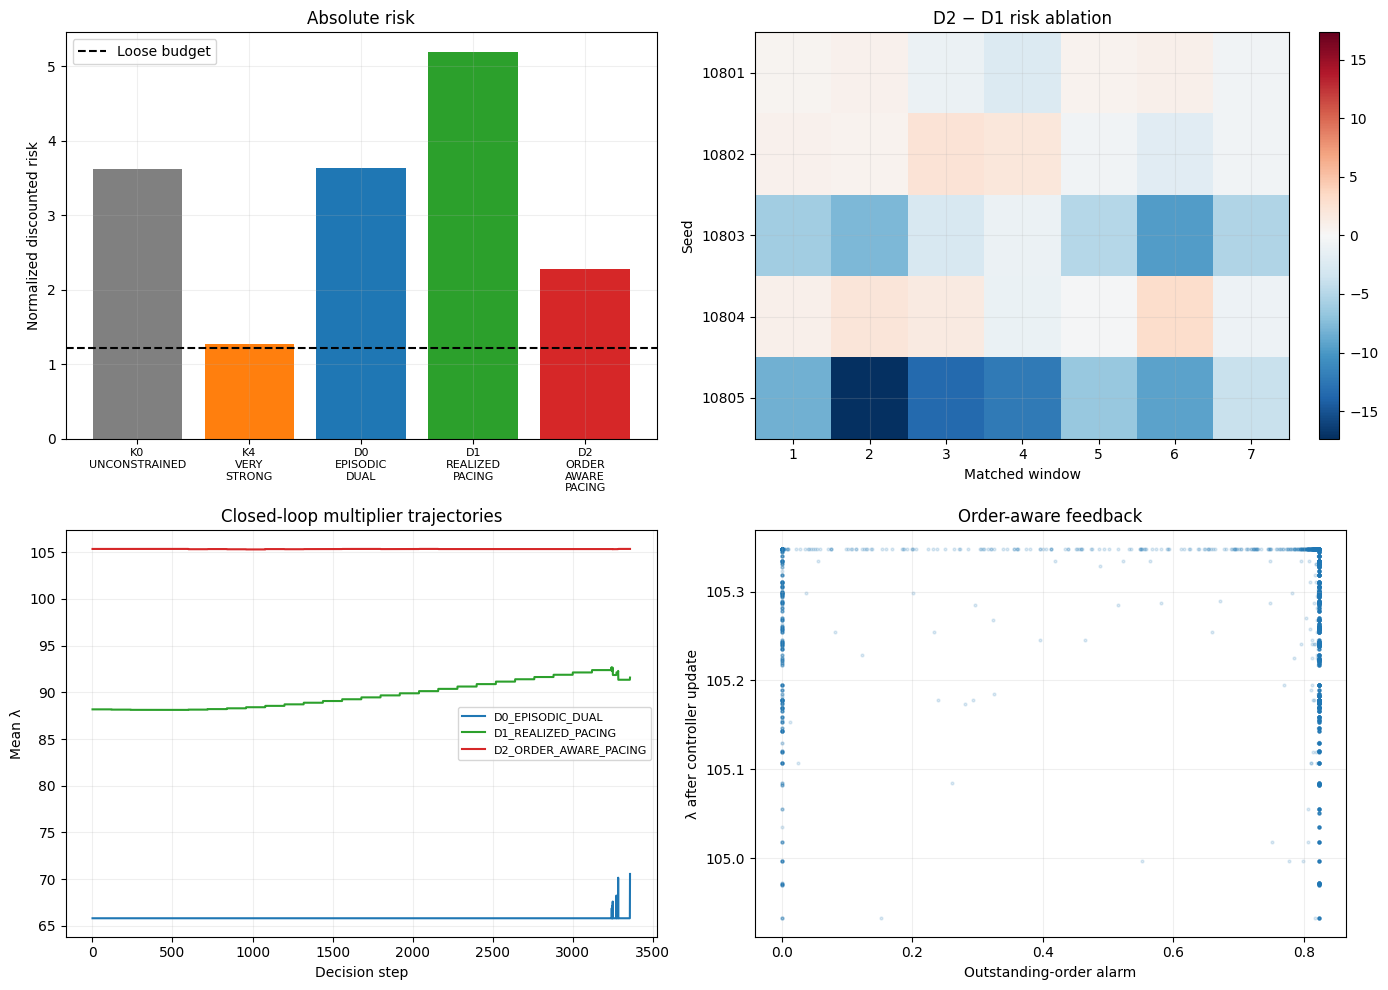

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_labels = ["K0_UNCONSTRAINED", "K4_VERY_STRONG", *ARM_LABELS]
x = np.arange(len(plot_labels))
means = [risk_matrices[label].mean() for label in plot_labels]
axes[0, 0].bar(x, means, color=["gray", "tab:orange", "tab:blue", "tab:green", "tab:red"])
axes[0, 0].axhline(TARGET_BUDGET, color="black", ls="--", label="Loose budget")
axes[0, 0].set_xticks(x, [s.replace("_", "\n") for s in plot_labels], fontsize=8)
axes[0, 0].set_ylabel("Normalized discounted risk")
axes[0, 0].set_title("Absolute risk")
axes[0, 0].legend()

proposed_diff = risk_matrices[PROPOSED_LABEL] - risk_matrices["D1_REALIZED_PACING"]
im = axes[0, 1].imshow(
    proposed_diff, aspect="auto", cmap="RdBu_r",
    vmin=-np.abs(proposed_diff).max(), vmax=np.abs(proposed_diff).max(),
)
axes[0, 1].set_xticks(range(len(VALIDATION_STARTS)), [str(i + 1) for i in range(len(VALIDATION_STARTS))])
axes[0, 1].set_yticks(range(len(MASTER_SEEDS)), [str(s) for s in MASTER_SEEDS])
axes[0, 1].set_xlabel("Matched window"); axes[0, 1].set_ylabel("Seed")
axes[0, 1].set_title("D2 − D1 risk ablation")
fig.colorbar(im, ax=axes[0, 1], fraction=.046)

for label, color in [("D0_EPISODIC_DUAL", "tab:blue"), ("D1_REALIZED_PACING", "tab:green"), (PROPOSED_LABEL, "tab:red")]:
    subset = adaptive_transitions[adaptive_transitions.label.eq(label)]
    trajectory = subset.groupby("step").lambda_after.mean()
    axes[1, 0].plot(trajectory.index, trajectory.values, label=label, color=color)
axes[1, 0].set_xlabel("Decision step"); axes[1, 0].set_ylabel("Mean λ")
axes[1, 0].set_title("Closed-loop multiplier trajectories")
axes[1, 0].legend(fontsize=8)

proposed_tr = adaptive_transitions[adaptive_transitions.label.eq(PROPOSED_LABEL)]
axes[1, 1].scatter(
    proposed_tr.order_alarm.sample(min(20_000, len(proposed_tr)), random_state=SEED),
    proposed_tr.lambda_after.sample(min(20_000, len(proposed_tr)), random_state=SEED),
    s=4, alpha=.15,
)
axes[1, 1].set_xlabel("Outstanding-order alarm")
axes[1, 1].set_ylabel("λ after controller update")
axes[1, 1].set_title("Order-aware feedback")
for ax in axes.ravel(): ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(V09_DIR / "v09_budget_paced_order_aware.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
proposed_budget = budget_df[budget_df.label.eq(PROPOSED_LABEL)].iloc[0]
proposed_summary = summary_df[summary_df.label.eq(PROPOSED_LABEL)].iloc[0]
d2_d1_risk = inference_df[
    inference_df.contrast.eq(f"risk:{PROPOSED_LABEL}-minus-D1_REALIZED_PACING")
    & inference_df.method.eq("crossed_iid")
].iloc[0]
d2_d0_risk = inference_df[
    inference_df.contrast.eq(f"risk:{PROPOSED_LABEL}-minus-D0_EPISODIC_DUAL")
    & inference_df.method.eq("crossed_iid")
].iloc[0]

order_signal_nondegenerate = bool(
    proposed_summary.order_alarm_positive_fraction > 0.001
    and proposed_summary.p95_committed_inventory_N > proposed_summary.p95_abs_inventory
)
budget_gate = bool(
    proposed_budget.crossed_ci_feasible and proposed_budget.block_ci_feasible
)
activity_gate = bool(
    proposed_summary.activity_ratio_vs_k0 >= V09_CFG["activity_floor_fraction"]
)
order_aware_increment_confirmed = bool(d2_d1_risk.ci_high < 0)
episodic_dual_improvement_confirmed = bool(d2_d0_risk.ci_high < 0)
d1_budget = budget_df[budget_df.label.eq("D1_REALIZED_PACING")].iloc[0]
order_aware_gate = bool(
    order_aware_increment_confirmed
    or (budget_gate and not bool(d1_budget.crossed_ci_feasible))
)

if budget_gate and activity_gate and order_signal_nondegenerate and order_aware_gate:
    route = "FREEZE_D2_FOR_SINGLE_OOS_TEST"
elif ((budget_gate or bool(d1_budget.crossed_ci_feasible)) and activity_gate):
    route = "PACING_WORKS_ORDER_AWARE_INCREMENT_NOT_ESTABLISHED"
else:
    route = "REPORT_NEGATIVE_RESULT_NO_OOS_AUTHORIZATION"

decision = dict(
    spec_id=SPEC_ID,
    method_digest=METHOD_DIGEST,
    complete_seeds=len(MASTER_SEEDS),
    windows_per_seed=len(VALIDATION_STARTS),
    primary_checkpoint=PRIMARY_EPISODE,
    proposed_label=PROPOSED_LABEL,
    target_budget=TARGET_BUDGET,
    proposed_risk=float(proposed_budget.point),
    proposed_crossed_ci=[float(proposed_budget.crossed_ci_low), float(proposed_budget.crossed_ci_high)],
    proposed_block_ci=[float(proposed_budget.block_ci_low), float(proposed_budget.block_ci_high)],
    proposed_budget_gate=budget_gate,
    activity_ratio_vs_k0=float(proposed_summary.activity_ratio_vs_k0),
    activity_gate=activity_gate,
    order_signal_nondegenerate=order_signal_nondegenerate,
    order_aware_increment=float(d2_d1_risk.point),
    order_aware_increment_ci=[float(d2_d1_risk.ci_low), float(d2_d1_risk.ci_high)],
    order_aware_increment_confirmed=order_aware_increment_confirmed,
    order_aware_gate=order_aware_gate,
    proposed_vs_episodic_dual=float(d2_d0_risk.point),
    proposed_vs_episodic_dual_ci=[float(d2_d0_risk.ci_low), float(d2_d0_risk.ci_high)],
    episodic_dual_improvement_confirmed=episodic_dual_improvement_confirmed,
    checkpoint_reselection_performed=False,
    controller_retuning_performed=False,
    fixed_penalty_retuning_performed=False,
    test_used=False,
    next_route=route,
)
atomic_json(decision, V09_DIR / "scientific_decision.json")
atomic_csv(pd.DataFrame([decision]), V09_DIR / "scientific_decision.csv")
display(pd.DataFrame([decision]))
print("=" * 78)
print("V0.9 ROUTE:", route)
print("D2 risk / budget:", decision["proposed_risk"], TARGET_BUDGET)
print("D2 crossed CI:", decision["proposed_crossed_ci"])
print("D2 moving-block CI:", decision["proposed_block_ci"])
print("D2 − D1 risk / CI:", decision["order_aware_increment"], decision["order_aware_increment_ci"])
print("activity ratio vs historical K0:", decision["activity_ratio_vs_k0"])
print("order signal non-degenerate:", decision["order_signal_nondegenerate"])
print("controller retuning: False")
print("checkpoint reselection: False")
print("test used: False")
print("=" * 78)


,spec_id,method_digest,complete_seeds,windows_per_seed,primary_checkpoint,proposed_label,target_budget,proposed_risk,proposed_crossed_ci,proposed_block_ci,...,order_aware_increment_confirmed,order_aware_gate,proposed_vs_episodic_dual,proposed_vs_episodic_dual_ci,episodic_dual_improvement_confirmed,checkpoint_reselection_performed,controller_retuning_performed,fixed_penalty_retuning_performed,test_used,next_route
0,v09_budget_paced_order_aware_20260927,9f8d01ab0542f8d4238d95f3e20e4831a86fdd9c31784a...,5,7,10,D2_ORDER_AWARE_PACING,1.214222,2.271556,"[1.3464083156407678, 3.5738681870503948]","[1.3597726330458504, 3.595114447441953]",...,False,False,-1.363221,"[-3.6302453769820033, 0.0468637085711531]",False,False,False,False,False,REPORT_NEGATIVE_RESULT_NO_OOS_AUTHORIZATION


V0.9 ROUTE: REPORT_NEGATIVE_RESULT_NO_OOS_AUTHORIZATION
D2 risk / budget: 2.271555911790485 1.2142215137929977
D2 crossed CI: [1.3464083156407678, 3.5738681870503948]
D2 moving-block CI: [1.3597726330458504, 3.595114447441953]
D2 − D1 risk / CI: -2.925045351680584 [-7.170738886594103, 0.4940876968796777]
activity ratio vs historical K0: 0.6617884121438586
order signal non-degenerate: True
controller retuning: False
checkpoint reselection: False
test used: False


# What to return

After all five seeds and validation cells finish, return the executed notebook.
The decisive artifacts are:

- `protocol.json` and its immutable method digest;
- `training_integrity_ep10.csv`;
- `adaptive_validation_episodes.csv`;
- `adaptive_validation_transitions.parquet`;
- `crossed_inference.csv`;
- `publication_summary.csv`;
- `budget_compliance.csv`;
- `v09_budget_paced_order_aware.png`;
- `scientific_decision.json` and the final `V0.9 ROUTE` block.

Interpretation must follow the frozen route. In particular, a non-zero order
signal is not evidence that the order-aware mechanism helps; the D2–D1 ablation
and its interval determine that claim. The test split remains untouched until a
separate, single-shot OOS notebook is authorized.
